# 🌍 Global Earthquake–Tsunami Risk Assessment Dataset

## 📘 Overview
The **Global Earthquake–Tsunami Risk Assessment Dataset** is a comprehensive, machine learning–ready dataset containing seismic characteristics and tsunami potential indicators for **782 significant earthquakes** recorded worldwide between **2001 and 2022**.  
It is designed for applications in **tsunami risk prediction**, **earthquake analysis**, and **seismic hazard assessment**.

---

## 📊 Dataset Summary

| Property | Description |
|-----------|--------------|
| **Records** | 782 earthquakes |
| **Time Period** | 2001–2022 (22 years) |
| **Geographic Coverage** | Global (Latitude: –61.85° → 71.63°, Longitude: –179.97° → 179.66°) |
| **File Format** | CSV (~41 KB) |
| **Missing Values** | None (100% complete) |
| **Target Variable** | `tsunami` — tsunami potential indicator (binary classification) |

---
·
---

In [1]:
import os, gc, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.10"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.10"):
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "2.2.5", 'matplotlib': "3.10.1",'sklearn': "1.6.1", 
                'pandas': "2.2.3",'xgboost': "3.0.0", 'shap': "0.47.2", 
                'polars': "1.27.1", 'seaborn': "0.13.2"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.12.10

[ OK ] numpy version 2.2.5 is installed.
[ OK ] matplotlib version 3.10.1 is installed.
[ OK ] sklearn version 1.6.1 is installed.
[ OK ] pandas version 2.2.3 is installed.
[ OK ] xgboost version 3.0.0 is installed.
[ OK ] shap version 0.47.2 is installed.
[ OK ] polars version 1.27.1 is installed.
[ OK ] seaborn version 0.13.2 is installed.


### 🌊 Problem Definition
Predict whether an earthquake will cause a **tsunami (1)** or **not (0)** based on seismic, geographic, and magnitude-related features.

### 🧩 Type
Supervised Machine Learning — **Binary Classification**

### 🎯 Objective
Train a model capable of identifying tsunami-prone earthquakes to support **early warning systems** and **disaster response planning**.

### 🚀 Why This Task
- **Highest practical significance:** directly tied to human safety and coastal disaster prevention.  
- **Scientifically challenging:** involves multi-dimensional, non-linear interactions among depth, magnitude, and epicenter coordinates.  
- **Balanced data:** supports reliable classification modeling.

In [2]:
# === Imports & Plot Config ===
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (9, 5.2)
plt.rcParams["figure.dpi"] = 140
sns.set_theme()

# For pretty display in notebooks
from IPython.display import display

In [3]:
# === Resolve Data Path (Auto-discover) ===
DATA_DIR = "/Users/tonylyu/Downloads/Project-Data1030/earthquake/earthquake_data_tsunami.csv"

# === Read In & Quick Glance ===
df = pd.read_csv(DATA_DIR) 

print(f"✅ Loaded {os.path.basename(DATA_DIR)} with shape {df.shape}")
display(df.head(3))

print("\nDtypes:")
display(df.dtypes)

mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"\nApprox memory usage: {mem_mb:.2f} MB")

✅ Loaded earthquake_data_tsunami.csv with shape (782, 13)


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.0,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.0,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.0,-20.0508,-178.346,2022,11,1



Dtypes:


magnitude    float64
cdi            int64
mmi            int64
sig            int64
nst            int64
dmin         float64
gap          float64
depth        float64
latitude     float64
longitude    float64
Year           int64
Month          int64
tsunami        int64
dtype: object


Approx memory usage: 0.08 MB


In [4]:
# === Duplicates & Key Uniqueness ===

# Full-row duplicate count
dup_rows = df.duplicated().sum()
print(f"Duplicate rows (entire row): {dup_rows}")

# Try common ID-style columns
candidate_id_cols = [c for c in df.columns if c.lower() in {"id", "event_id", "earthquake_id", "row_id"}]
if len(candidate_id_cols) > 0:
    for c in candidate_id_cols:
        print(f"{c} unique:", df[c].is_unique)
else:
    # If no clear ID column, try a quasi-key based on typical seismo features
    combo_keys = [
        ["latitude", "longitude", "Year", "Month", "magnitude", "depth"],
        ["latitude", "longitude", "Year", "magnitude", "depth"],
        ["latitude", "longitude", "magnitude", "depth"]
    ]
    tested = False
    for keys in combo_keys:
        if set(keys).issubset(df.columns):
            uniq = df[keys].drop_duplicates().shape[0]
            print(f"unique({keys}) vs rows: {uniq} / {len(df)}")
            tested = True
            break
    if not tested:
        print("No full key available to test uniqueness (no typical ID/composite keys found).")

Duplicate rows (entire row): 0
unique(['latitude', 'longitude', 'Year', 'Month', 'magnitude', 'depth']) vs rows: 780 / 782


In [5]:
subset_keys = ["latitude", "longitude", "Year", "Month", "magnitude", "depth"]

dup_mask = df.duplicated(subset=subset_keys, keep=False)
dups = df[dup_mask].sort_values(subset_keys)

print(f"🔍 Found {dups.shape[0]} rows sharing identical composite keys "
      f"({len(dups[subset_keys].drop_duplicates())} unique key groups).")

display(
    dups[
        subset_keys + [c for c in df.columns if c not in subset_keys]
    ].reset_index(drop=True)
)

🔍 Found 4 rows sharing identical composite keys (2 unique key groups).


,latitude,longitude,Year,Month,magnitude,depth,cdi,mmi,sig,nst,dmin,gap,tsunami
0,52.480,-167.736,2022,1,6.7,33.0,0,4,691,50,0.936943,126.0,1
1,52.480,-167.736,2022,1,6.7,33.0,0,4,691,20,0.000000,205.2,1
2,52.502,-168.080,2022,1,6.5,37.0,0,3,650,97,1.616070,108.0,1
3,52.502,-168.080,2022,1,6.5,37.0,0,3,650,23,0.000000,208.8,1


In [6]:
# === Missingness Overview ===
missing = df.isna().mean().sort_values(ascending=False)
print("\nMissing fraction (top 15):")
display(missing.head(15))

miss_nonzero = missing[missing > 0]
if len(miss_nonzero) > 0:
    plt.figure()
    sns.barplot(x=miss_nonzero.values, y=miss_nonzero.index)
    plt.title("Missingness by Feature")
    plt.xlabel("Fraction missing")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected ✅")


Missing fraction (top 15):


magnitude    0.0
cdi          0.0
mmi          0.0
sig          0.0
nst          0.0
dmin         0.0
gap          0.0
depth        0.0
latitude     0.0
longitude    0.0
Year         0.0
Month        0.0
tsunami      0.0
dtype: float64

No missing values detected ✅


### Distributions by Feature Groups

We plot histograms (with KDE) for seismic-related groups:

- **Magnitude**: `magnitude`
- **Intensity**: `cdi`, `mmi`, `sig`
- **Network/Quality**: `nst`, `dmin`, `gap`
- **Depth**: `depth`
- **Geographic**: `latitude`, `longitude`
- **Temporal**: `Year`, `Month`

Then we compute a **numeric-only correlation heatmap**, and list **top correlations with the target** (`tsunami`).


=== Magnitude ===


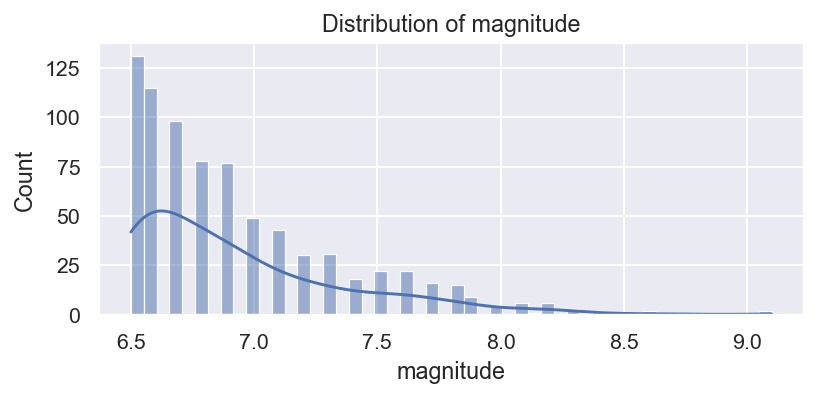


=== Intensity ===


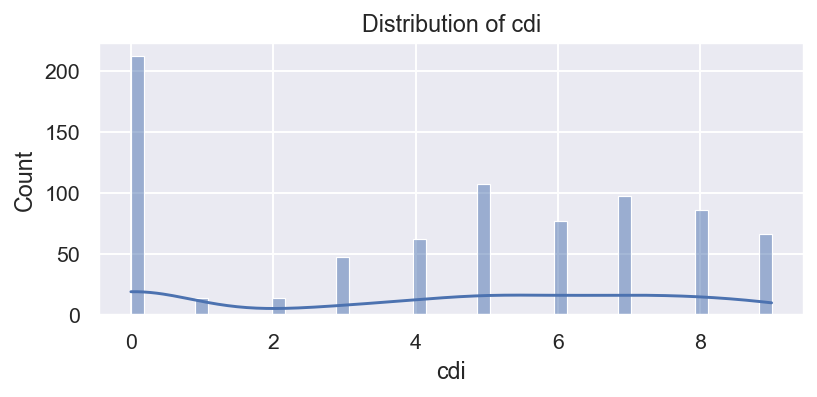

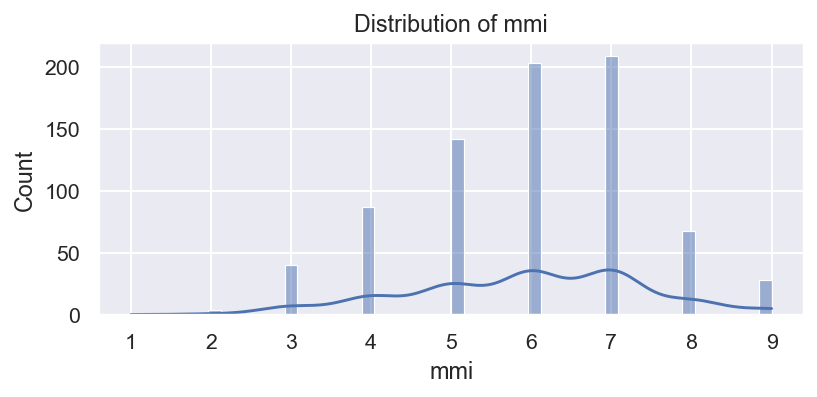

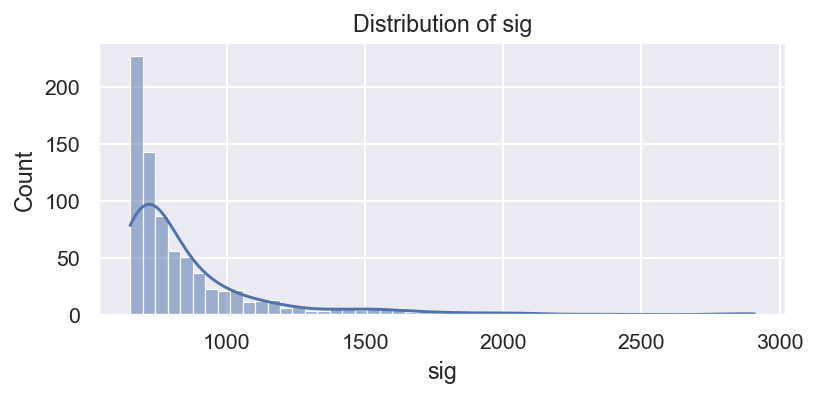


=== Network/Quality ===


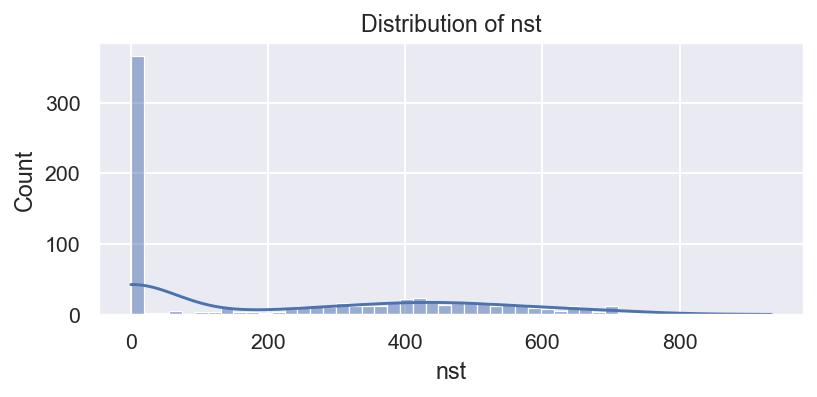

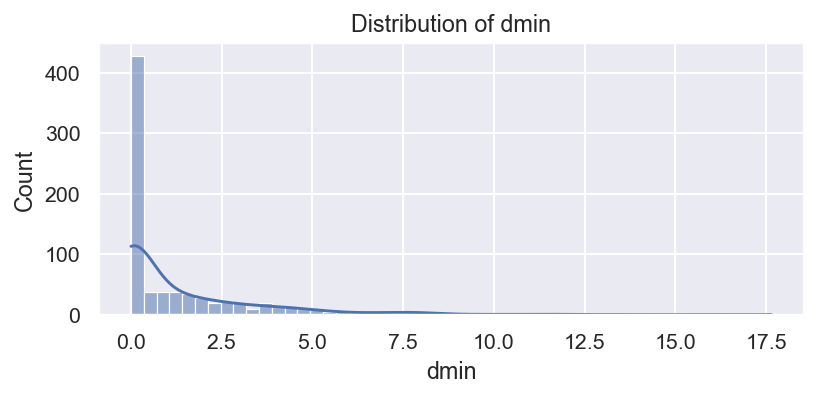

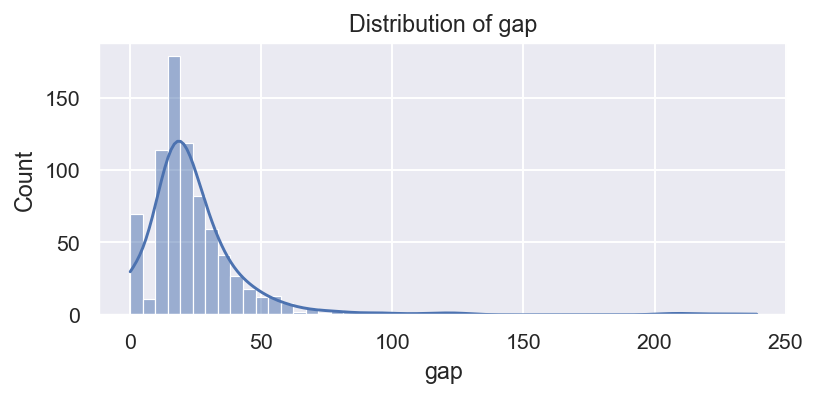


=== Depth ===


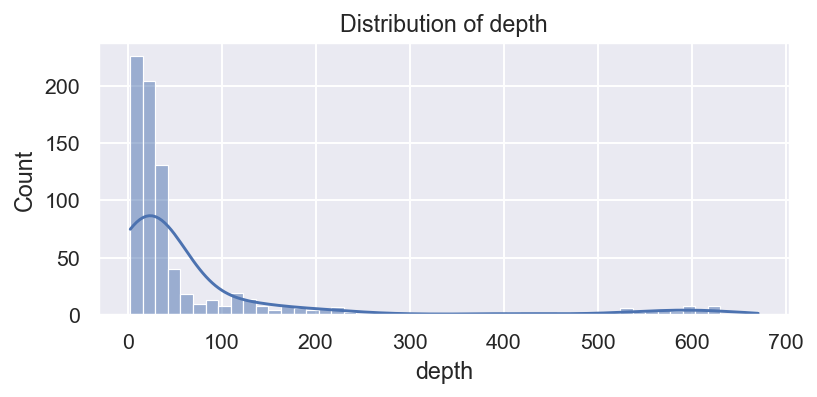


=== Geographic ===


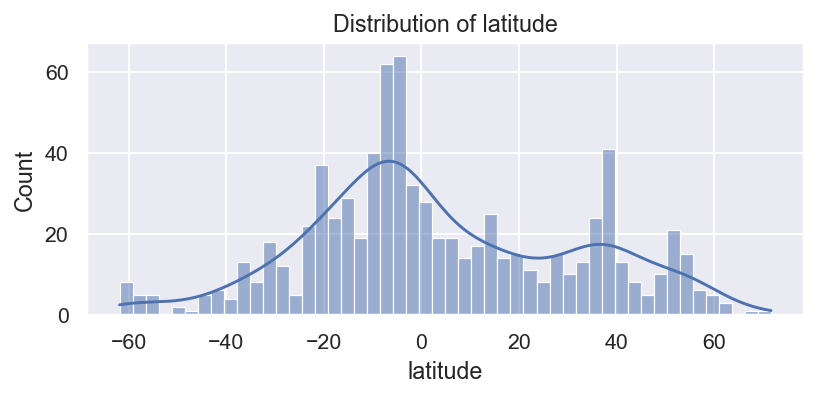

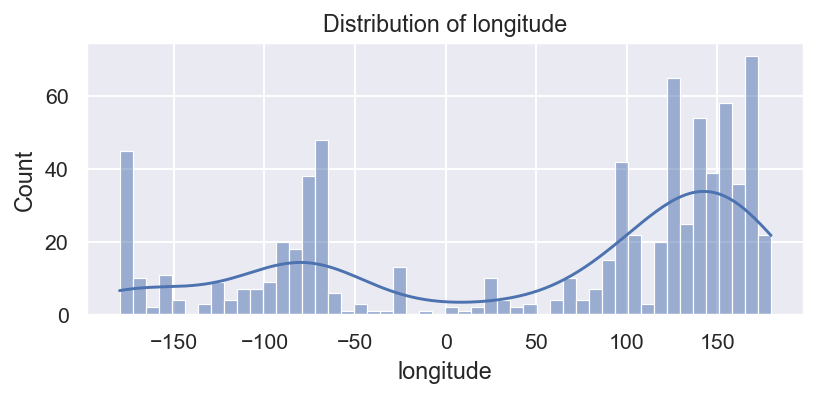


=== Temporal ===


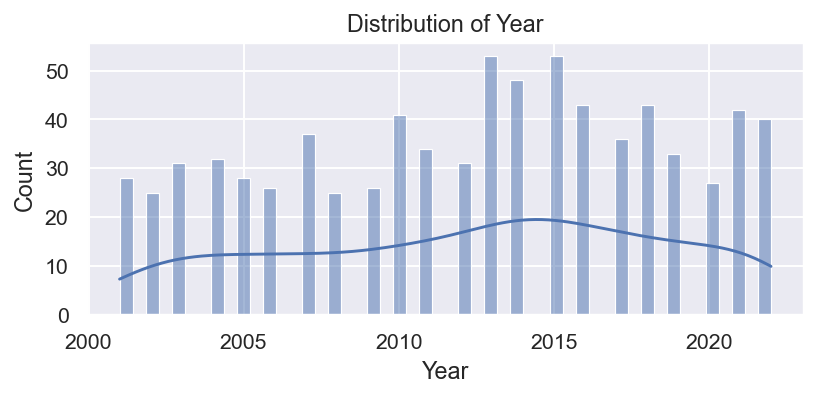

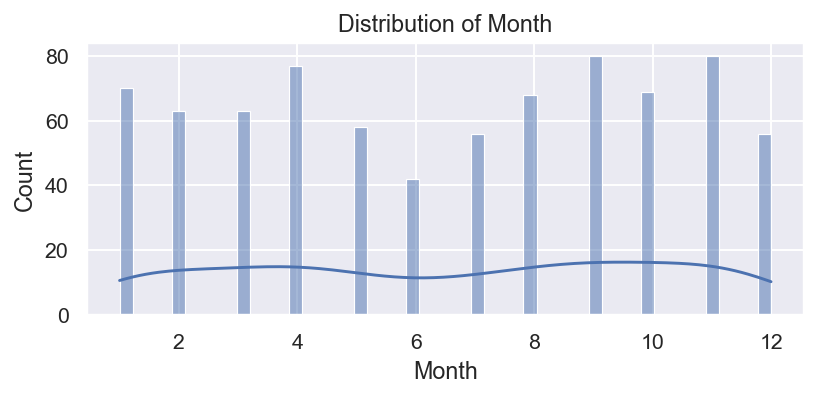

In [7]:
# --- Helpers & Grouped Distributions ---

# Numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Define groups (only keep those present in the dataframe)
group_map = {
    "Magnitude": ["magnitude"],
    "Intensity": ["cdi", "mmi", "sig"],
    "Network/Quality": ["nst", "dmin", "gap"],
    "Depth": ["depth"],
    "Geographic": ["latitude", "longitude"],
    "Temporal": ["Year", "Month"],
}

# Filter to existing columns and numeric only
for k, cols in list(group_map.items()):
    group_map[k] = [c for c in cols if c in numeric_cols]
    if len(group_map[k]) == 0:
        group_map.pop(k, None)

def quick_hist(series, title):
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.histplot(series.dropna(), bins=50, kde=True, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Plot each group
for grp, cols in group_map.items():
    print(f"\n=== {grp} ===")
    for c in cols:
        quick_hist(df[c], f"Distribution of {c}")

✅ Figure saved to: graph/tsunami_target_distribution.png


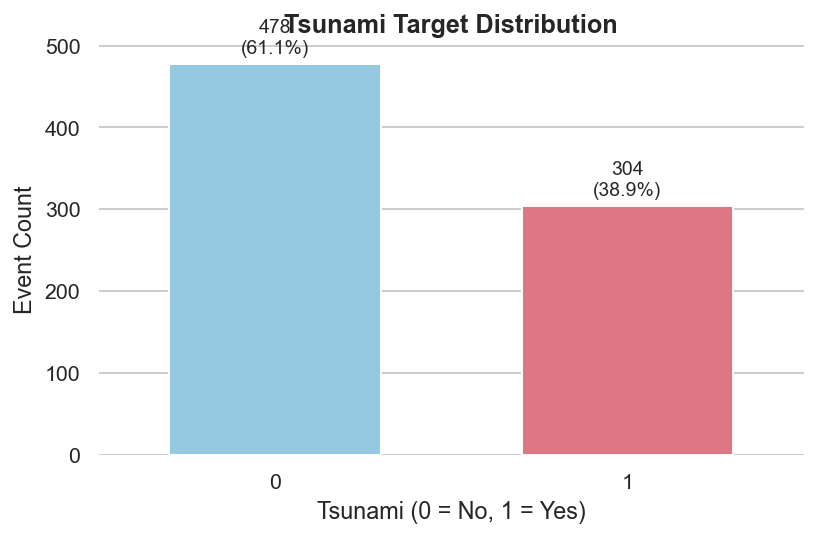

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df, x="tsunami", palette=["#88CCEE", "#EE6677"], width=0.6
)
# add count + percentage labels
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    frac = count / total
    ax.text(
        p.get_x() + p.get_width()/2, p.get_height() + total*0.01,
        f"{count}\n({frac:.1%})",
        ha="center", va="bottom", fontsize=10, fontweight="medium"
    )

ax.set_title("Tsunami Target Distribution", fontsize=13, weight="bold")
ax.set_xlabel("Tsunami (0 = No, 1 = Yes)")
ax.set_ylabel("Event Count")
sns.despine(left=True, bottom=True)
plt.tight_layout()

# save
import os
os.makedirs("graph", exist_ok=True)
save_path = "graph/tsunami_target_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Figure saved to: {save_path}")

plt.show()

### Correlation Heatmap (Numeric Features)

We compute the Pearson correlation among numeric features to quickly spot linear relationships and potential multicollinearity.

✅ Figure saved to: graph/correlation_heatmap_numeric.png


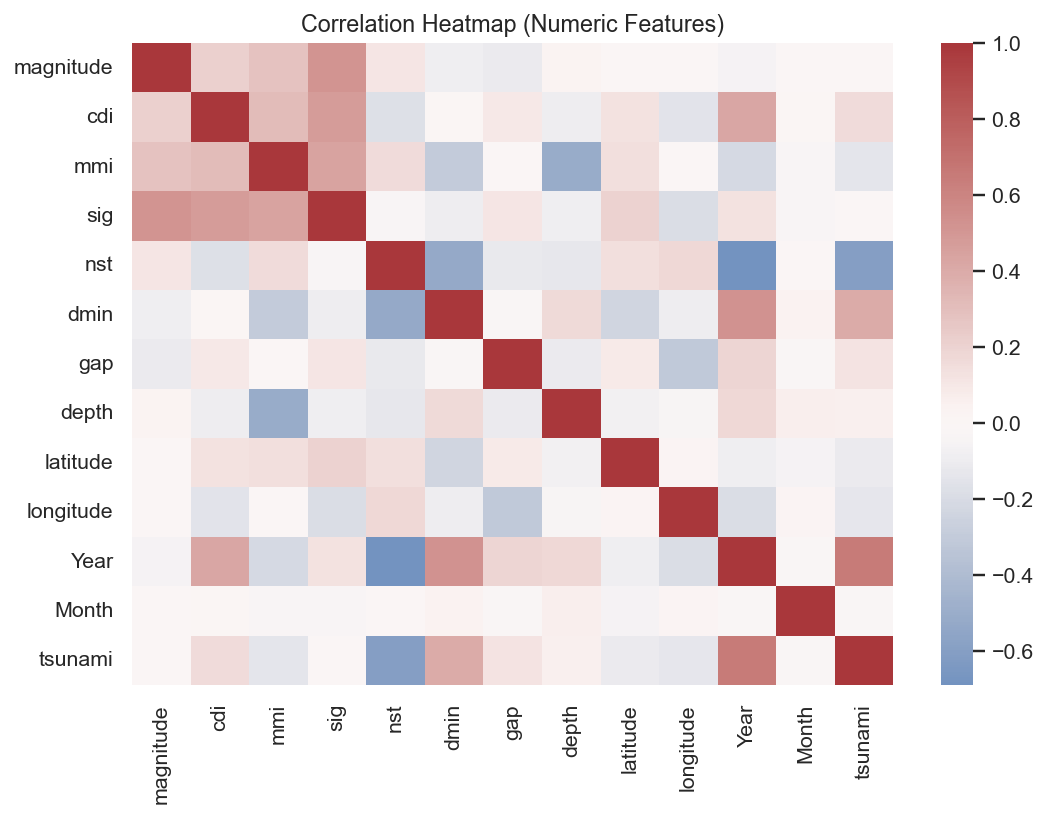

In [9]:
import os

# --- Correlation heatmap (numeric only) ---
corr = df.select_dtypes(include=[np.number]).corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()

# === Save to graph folder ===
os.makedirs("graph", exist_ok=True)
save_path = "graph/correlation_heatmap_numeric.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Figure saved to: {save_path}")

plt.show()

### Interpretation

- Strong positive links among `magnitude`, `sig`, and `mmi` → they describe overall quake intensity.  
- `nst`, `dmin`, and `gap` correlate within the **network quality** group (more stations → smaller gap/distance).  
- `depth`, `latitude`, and `longitude` show weak or no correlation with others → mostly independent spatial factors.  
- `Year` trends upward with reporting quality but has no physical meaning.  

**Takeaway:**  
Features form two main clusters — **intensity** and **observation quality** — with limited multicollinearity, suitable for downstream modeling after scaling.

### Top Correlations with Target (`tsunami`)

We sort and display numeric correlations with the target to identify strong drivers.

In [10]:
# --- Top correlations with target (if available) ---
target_col = "tsunami"
if target_col in df.columns and target_col in corr.columns:
    ct = corr[target_col].drop(labels=[target_col], errors="ignore").sort_values(ascending=False)
    print("\nTop positive correlations with 'tsunami':")
    display(ct.head(10))
    print("\nTop negative correlations with 'tsunami':")
    display(ct.tail(10))
else:
    print(f"Target column '{target_col}' not found in correlation matrix.")


Top positive correlations with 'tsunami':


Year         0.647211
dmin         0.400752
cdi          0.160266
gap          0.116360
depth        0.056814
magnitude   -0.004726
sig         -0.015500
Month       -0.022028
latitude    -0.113209
longitude   -0.136778
Name: tsunami, dtype: float64


Top negative correlations with 'tsunami':


cdi          0.160266
gap          0.116360
depth        0.056814
magnitude   -0.004726
sig         -0.015500
Month       -0.022028
latitude    -0.113209
longitude   -0.136778
mmi         -0.147363
nst         -0.600231
Name: tsunami, dtype: float64

### One-Shot Panel: All Columns at a Glance

We render an automatic panel:
- Numeric columns → histograms (heavy-tailed columns are shown in `log1p` view for visualization only).
- Categorical-like columns → top-level bar charts.
- We also print the detected numeric vs categorical-like columns.

This panel is purely exploratory and does **not** mutate the data.

✅ Figure saved to: graph/one_shot_panel_exclude_target.png


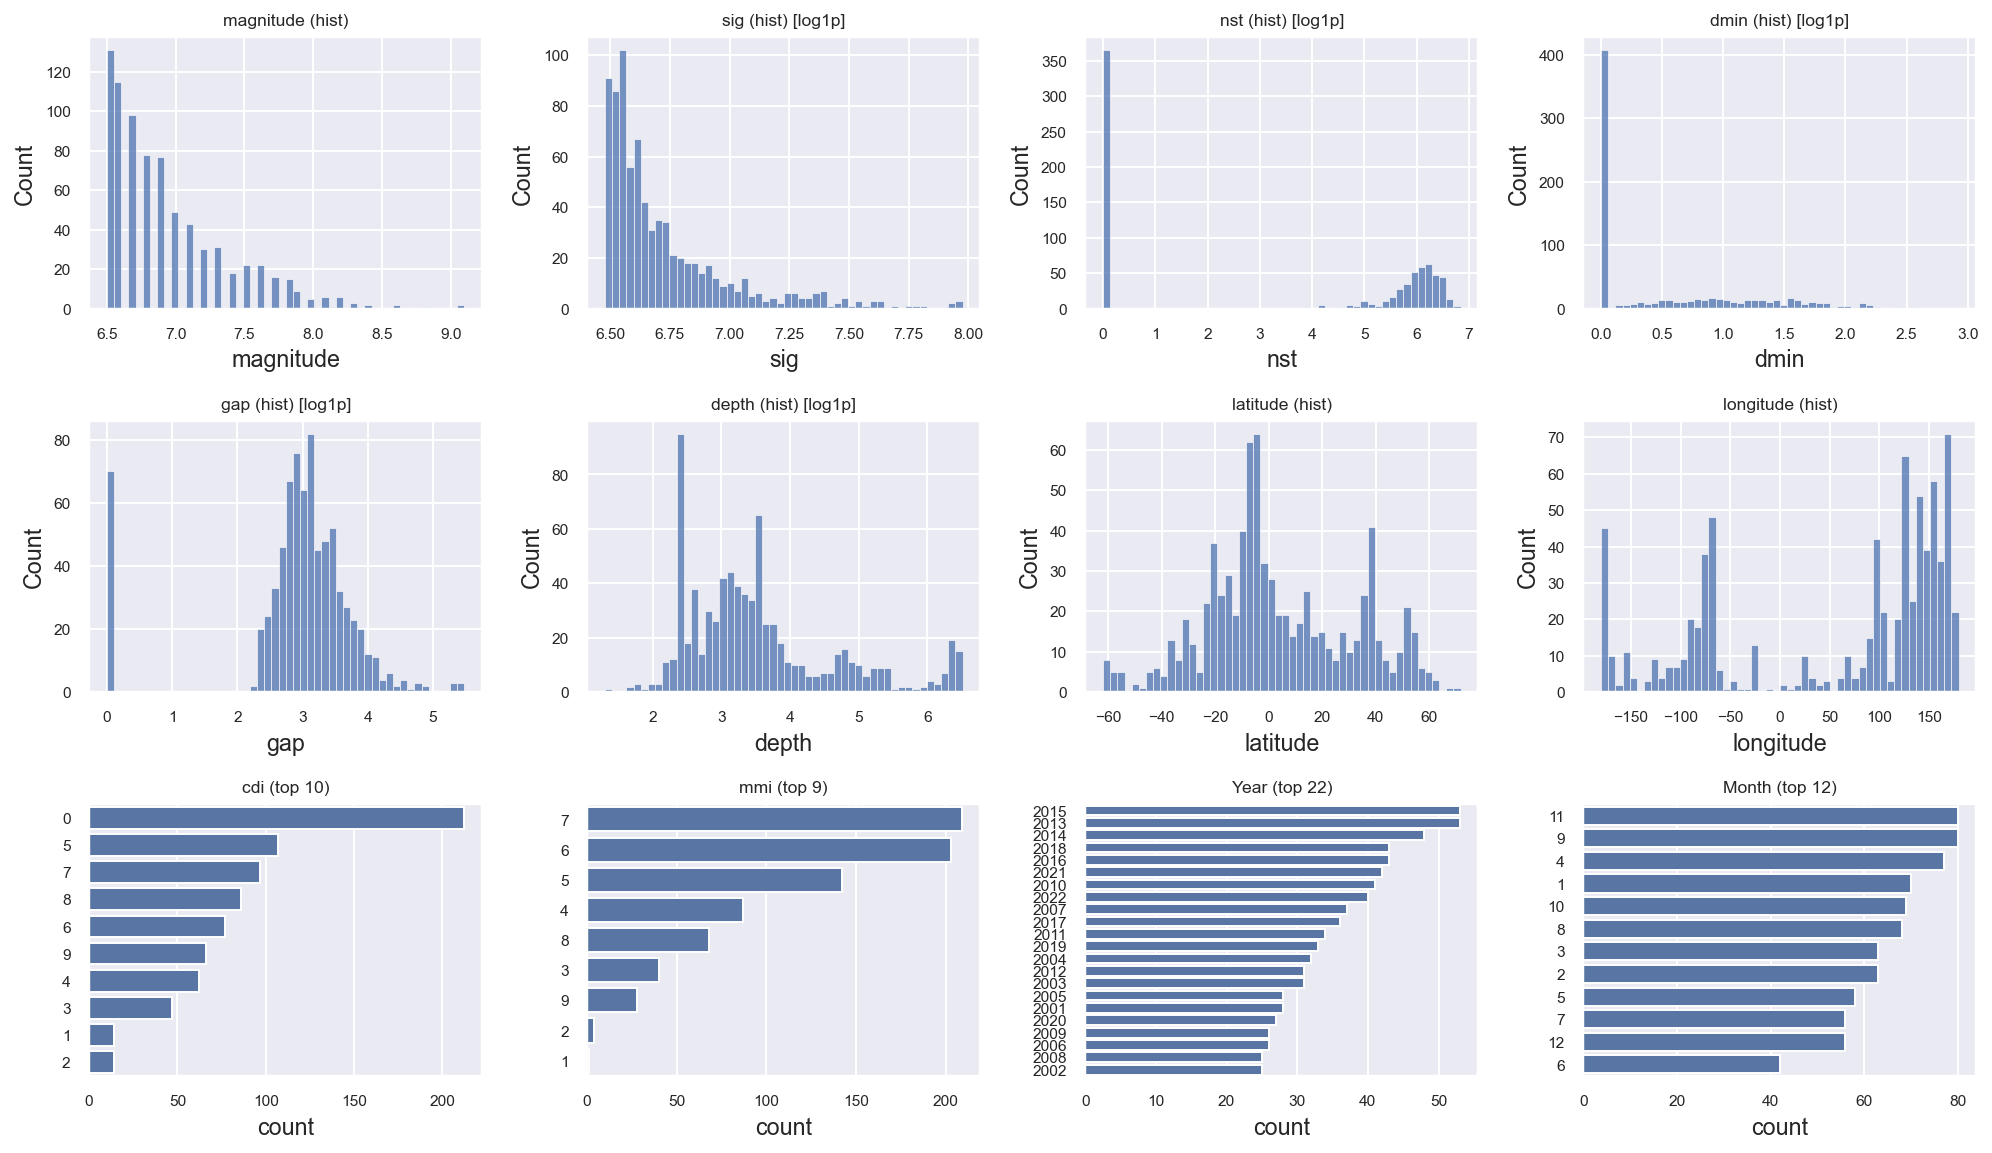

Excluded: ('tsunami',)

Numeric (8): ['magnitude', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude']
Categorical-like (4): ['cdi', 'mmi', 'Year', 'Month']


In [11]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme()
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 140

from pandas.api.types import (
    is_bool_dtype, is_categorical_dtype, is_object_dtype, is_integer_dtype, is_numeric_dtype
)

TARGET = "tsunami"  # will be excluded from plots

def _is_categorical_series(s, max_unique_ratio=0.05, max_levels=40):
    try:
        if is_bool_dtype(s) or is_categorical_dtype(s) or is_object_dtype(s):
            return True
        if is_integer_dtype(s):
            nunq = s.nunique(dropna=True)
            return (nunq <= max_levels) and (nunq / max(len(s), 1) <= max_unique_ratio)
    except Exception:
        pass
    return False

def _coerce_numeric_if_object(df):
    dfx = df.copy()
    for c in dfx.columns:
        if is_object_dtype(dfx[c]):
            try:
                dfx[c] = pd.to_numeric(dfx[c], errors="raise")
            except Exception:
                pass
    return dfx

def one_shot_panel_exclude(df, exclude=("tsunami",),
                           sample_n=80000, max_levels=30,
                           log1p_for=("nst","dmin","sig","gap","depth"),
                           ncols=4):
    dfx = _coerce_numeric_if_object(df)
    exclude = tuple(exclude) if isinstance(exclude, (list, tuple, set)) else (exclude,)
    keep_cols = [c for c in dfx.columns if c not in exclude]
    dfx = dfx[keep_cols]

    num_cols = [c for c in dfx.columns if is_numeric_dtype(dfx[c])]
    cat_cols = [c for c in dfx.columns if c not in num_cols or _is_categorical_series(dfx[c])]
    cat_cols = list(dict.fromkeys(cat_cols))
    num_cols = [c for c in num_cols if c not in cat_cols]

    if len(dfx) > sample_n:
        dfx = dfx.sample(sample_n, random_state=7)

    cols_order = num_cols + cat_cols
    k = len(cols_order)
    nrows = int(np.ceil(k / ncols)) if k else 1
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3.6*ncols, 2.8*nrows))
    axes = np.array(axes).reshape(-1) if k > 1 else np.array([axes])

    for i, c in enumerate(cols_order):
        ax = axes[i]
        s = dfx[c]
        if c in num_cols:
            s_plot = s.copy()
            if any(key in c.lower() for key in log1p_for) and (s_plot.dropna() >= 0).all():
                s_plot = np.log1p(s_plot)
                title = f"{c} (hist) [log1p]"
            else:
                title = f"{c} (hist)"
            sns.histplot(s_plot.dropna(), bins=50, ax=ax)
            ax.set_title(title, fontsize=9)
        else:
            vc = s.astype("object").value_counts(dropna=False).head(max_levels)
            sns.barplot(x=vc.values, y=[str(x) for x in vc.index], ax=ax)
            ax.set_title(f"{c} (top {len(vc)})", fontsize=9)
            ax.set_xlabel("count")
        ax.tick_params(labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()

    # === save figure ===
    import os
    os.makedirs("graph", exist_ok=True)
    save_path = "graph/one_shot_panel_exclude_target.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"✅ Figure saved to: {save_path}")

    plt.show()

    print(f"Excluded: {exclude}")
    print(f"\nNumeric ({len(num_cols)}):", num_cols)
    print(f"Categorical-like ({len(cat_cols)}):", cat_cols)
    return num_cols, cat_cols

# === run (exclude target) ===
num_cols_auto, cat_cols_auto = one_shot_panel_exclude(df, exclude=(TARGET,))

### EDA Takeaways (excluding the target)

**Magnitude (`magnitude`)**  
- Right-skewed with a hard lower cutoff at 6.5 and a long, thin tail to ~9.1.  
- Interpretation: the truncated range reduces linear correlation with tsunami outcomes; interactions (e.g., with `depth`) will be more informative than magnitude alone.

**Event Significance (`sig`)**  
- Strongly right-tailed (few very large values).  
- Interpretation: likely aggregates multiple signals (magnitude, felt intensity, damage proxies). Use with care to avoid proxy-leakage; consider log1p transform.

**Network/Quality (`nst`, `dmin`, `gap`)**  
- `nst` (station count): bimodal/long-tailed after log1p; many small values, some very large.  
- `dmin` (nearest station distance): heavy right tail; many near-zero observations with a long tail to large distances.  
- `gap` (azimuthal gap): unimodal but skewed; long upper tail.  
- Interpretation: these are *measurement/coverage* proxies correlated with geography (offshore vs onshore). Expect confounding with location; transformations (log1p or winsorization) help stabilize scale.

**Depth (`depth`)**  
- Extremely right-skewed with clusters at shallow depths and a sparse long tail down to ~670 km.  
- Interpretation: shallow events are common and physically more relevant to tsunami generation; binning or non-linear effects (splines/trees) will likely outperform linear terms.

**Geographic (`latitude`, `longitude`)**  
- Multi-modal distributions reflecting tectonic belts (e.g., circum-Pacific).  
- Interpretation: raw lat/long are difficult for linear models; consider engineered geospatial features (e.g., coastal proximity, trench distance, or regional bins).

**Temporal (`Year`, `Month`)**  
- `Year` shows a pronounced trend (more records in later years); `Month` varies mildly.  
- Interpretation: the year trend captures reporting/selection effects rather than physics. If used, prefer time-aware splits and clearly state its non-causal nature; otherwise exclude or treat as a control.

---

#### Practical preprocessing implications
- Apply **log1p** to heavy-tailed variables (`sig`, `nst`, `dmin`, `gap`, `depth`) before scaling.  
- Use **standardization** for numeric features; consider **winsorization** at extreme percentiles.  
- Model **non-linearities/interactions**: e.g., `magnitude × I(depth < 50 km)`.  
- Treat `Year` as a potential **confounder/time proxy**; validate with **temporal splits**.  
- Replace raw lat/long with **region bins** or external geospatial distances if available.

### Univariate: Categorical Bar Charts (Counts & Fractions)

We plot selected categorical-like variables as horizontal bars.  
Each bar shows the **count**, and labels include the **fraction** of the dataset.

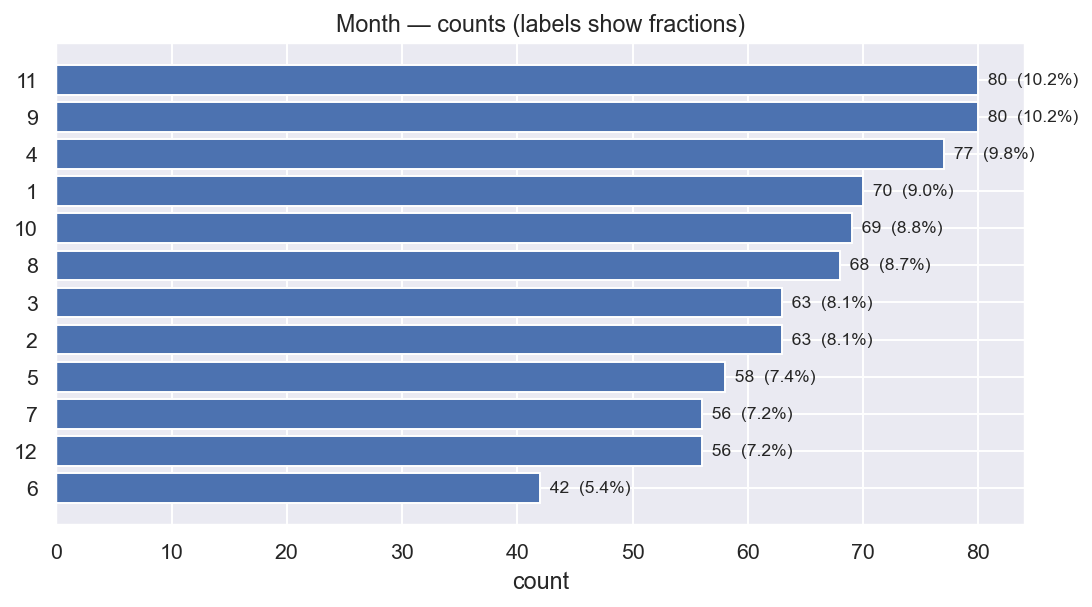

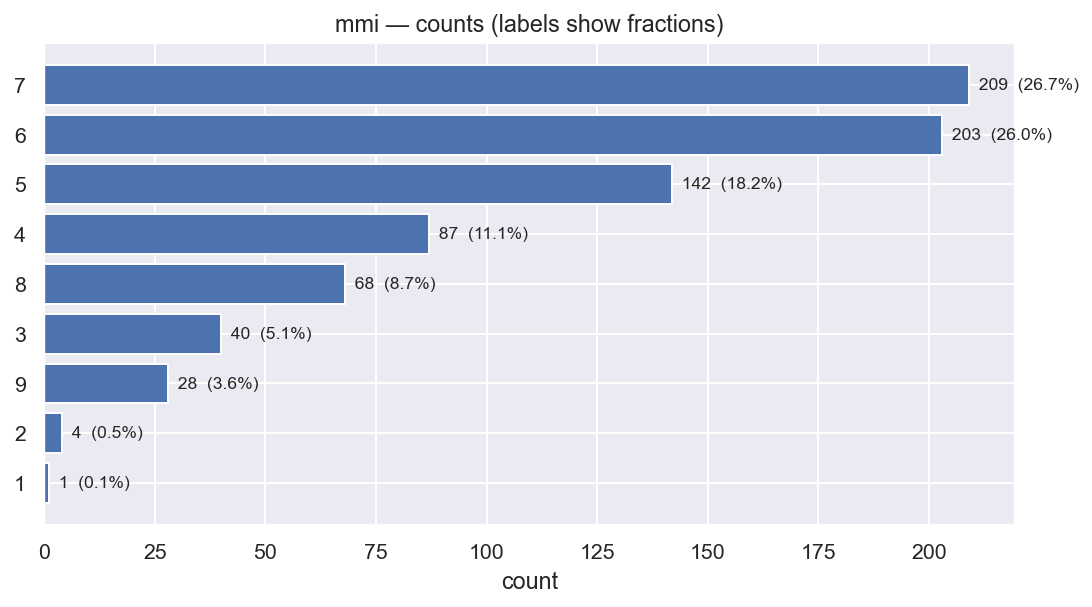

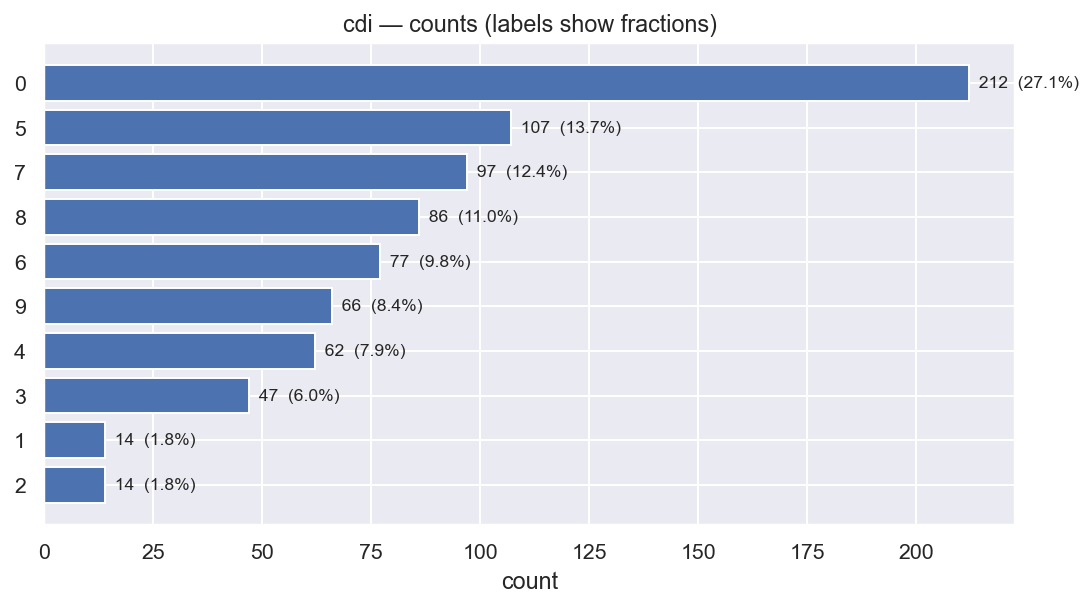

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 140

TARGET = "tsunami"

# Heuristic: treat small-cardinality integer columns as categorical-like
def cat_like_cols(df, exclude=(TARGET,), max_levels=20):
    cols = []
    for c in df.columns:
        if c in exclude: 
            continue
        s = df[c]
        if pd.api.types.is_bool_dtype(s) or pd.api.types.is_categorical_dtype(s) or pd.api.types.is_object_dtype(s):
            cols.append(c)
        elif pd.api.types.is_integer_dtype(s) and s.nunique(dropna=True) <= max_levels:
            cols.append(c)
    return cols

def plot_cat_barh(df, col, top_n=None):
    vc = df[col].astype("object").value_counts(dropna=False)
    if top_n:
        vc = vc.head(top_n)
    frac = vc / len(df)
    order = vc.index[::-1]  # largest at top in barh
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh([str(x) for x in order], vc[order].values)
    for y, v in enumerate(vc[order].values):
        ax.text(v, y, f"  {v}  ({v/len(df):.1%})", va="center", ha="left", fontsize=9)
    ax.set_title(f"{col} — counts (labels show fractions)")
    ax.set_xlabel("count")
    plt.tight_layout()
    plt.show()

cats = cat_like_cols(df, exclude=(TARGET,), max_levels=20)

# Pick a few readable categorical-like variables commonly present in this dataset
preferred = [c for c in ["Month", "mmi", "cdi", "Year"] if c in cats]
to_plot = preferred or cats[:3]  # fallback

for c in to_plot:
    plot_cat_barh(df, c)

### Continuous × Continuous (Scatter + 2D Histogram)

We visualize a key continuous pair with both a **scatter** (for structure) and a **2D histogram/hexbin** (for density).

✅ Figure saved to: graph/magnitude_vs_depth_overlay_hexbin_triptych.png


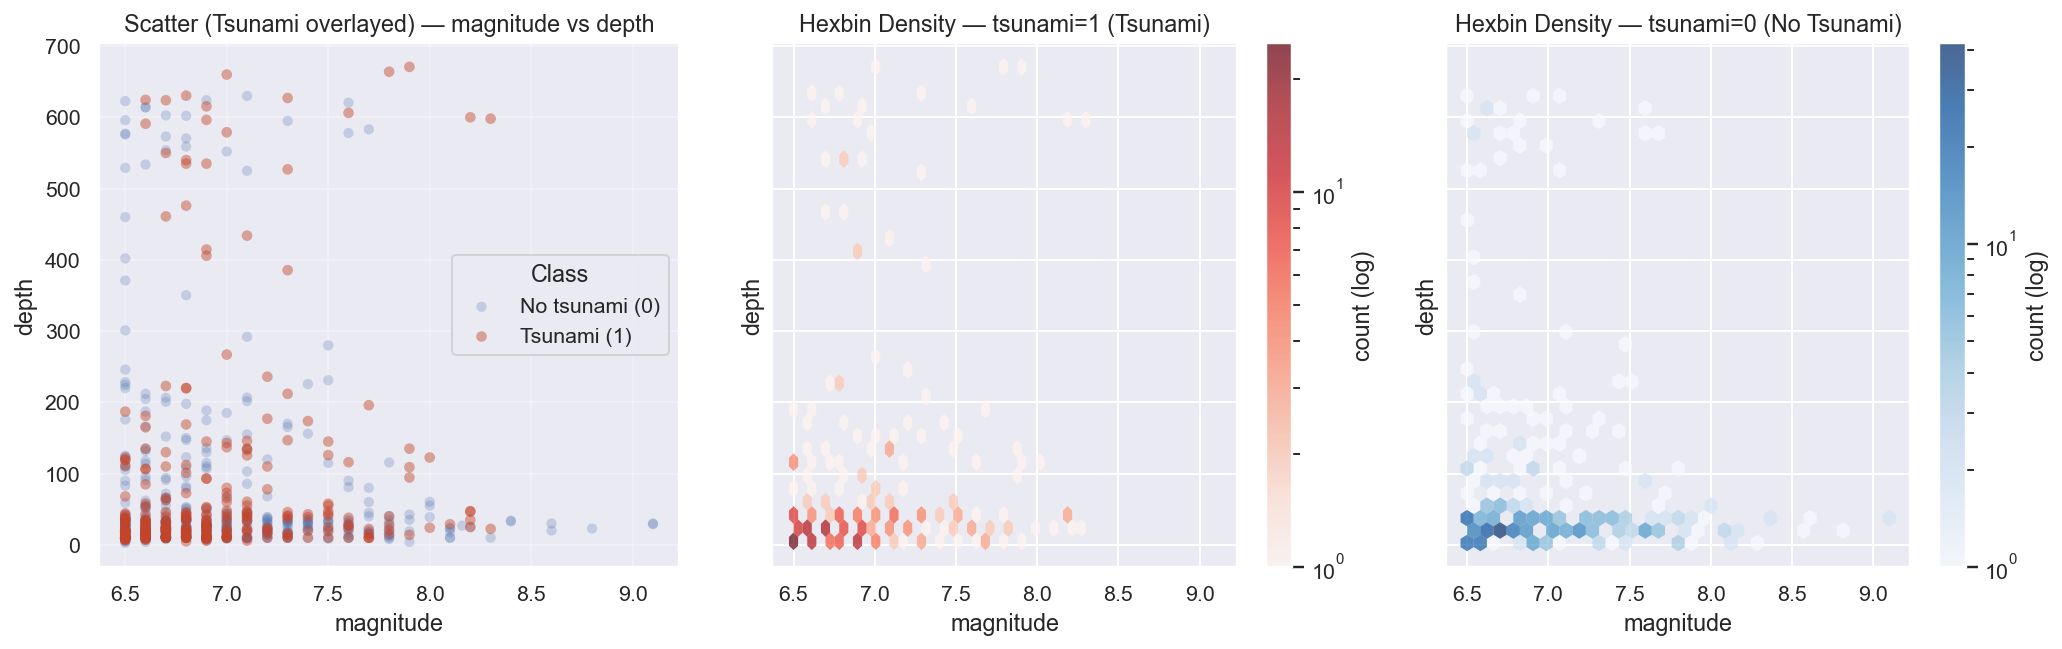

In [13]:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

TARGET = "tsunami"
assert TARGET in df.columns, "TARGET column missing."

x = "magnitude" if "magnitude" in df.columns else df.select_dtypes(np.number).columns[0]
y = "depth"     if "depth"     in df.columns else next(c for c in df.select_dtypes(np.number).columns if c != x)

# Palettes and subsets
cls_palette = {0: "#4C72B0", 1: "#C4442A"}   # blue / deep red
hex_cmap_0 = "Blues"
hex_cmap_1 = "Reds"

d0 = df[df[TARGET] == 0]
d1 = df[df[TARGET] == 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

# --- 1️⃣ Scatter: tsunami overlayed on non-tsunami ---
sns.scatterplot(
    data=d0, x=x, y=y, color=cls_palette[0], alpha=0.25, s=28, edgecolor="none", ax=axes[0]
)
sns.scatterplot(
    data=d1, x=x, y=y, color=cls_palette[1], alpha=0.45, s=30, edgecolor="none", ax=axes[0]
)
axes[0].set_title(f"Scatter (Tsunami overlayed) — {x} vs {y}")
axes[0].set_xlabel(x); axes[0].set_ylabel(y)
axes[0].grid(True, alpha=0.25)
axes[0].legend(["No tsunami (0)", "Tsunami (1)"], loc="best", title="Class")

# --- 2️⃣ Hexbin: tsunami=1 ---
hb1 = axes[1].hexbin(
    d1[x], d1[y], gridsize=32, mincnt=1, cmap=hex_cmap_1,
    norm=LogNorm(), linewidths=0, alpha=0.7
)
axes[1].set_title(f"Hexbin Density — {TARGET}=1 (Tsunami)")
axes[1].set_xlabel(x); axes[1].set_ylabel(y)
cb1 = fig.colorbar(hb1, ax=axes[1]); cb1.set_label("count (log)")

# --- 3️⃣ Hexbin: tsunami=0 ---
hb0 = axes[2].hexbin(
    d0[x], d0[y], gridsize=32, mincnt=1, cmap=hex_cmap_0,
    norm=LogNorm(), linewidths=0, alpha=0.7
)
axes[2].set_title(f"Hexbin Density — {TARGET}=0 (No Tsunami)")
axes[2].set_xlabel(x); axes[2].set_ylabel(y)
cb0 = fig.colorbar(hb0, ax=axes[2]); cb0.set_label("count (log)")

plt.tight_layout()
os.makedirs("graph", exist_ok=True)
out_path = f"graph/{x}_vs_{y}_overlay_hexbin_triptych.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"✅ Figure saved to: {out_path}")
plt.show()

### Interpretation (Magnitude vs Depth)

- Strong overlap between classes ⇒ magnitude and depth alone have **low discriminative power**.
- Slight tendency: tsunamis more often at **shallower** depths and **higher** magnitudes, but separation is weak.
- Magnitude/depth help a bit, but **better features are required** for meaningful separation.

### Bivariate: Numeric × Categorical — Overlaid Histogram + Box + Violin

We compare a numeric feature across levels of a categorical-like feature in one figure:
1) **Overlaid histogram** (faceted by category)  
2) **Box plot**  
3) **Violin plot**

✅ Figure saved to: graph/magnitude_by_Month_bivariate.png


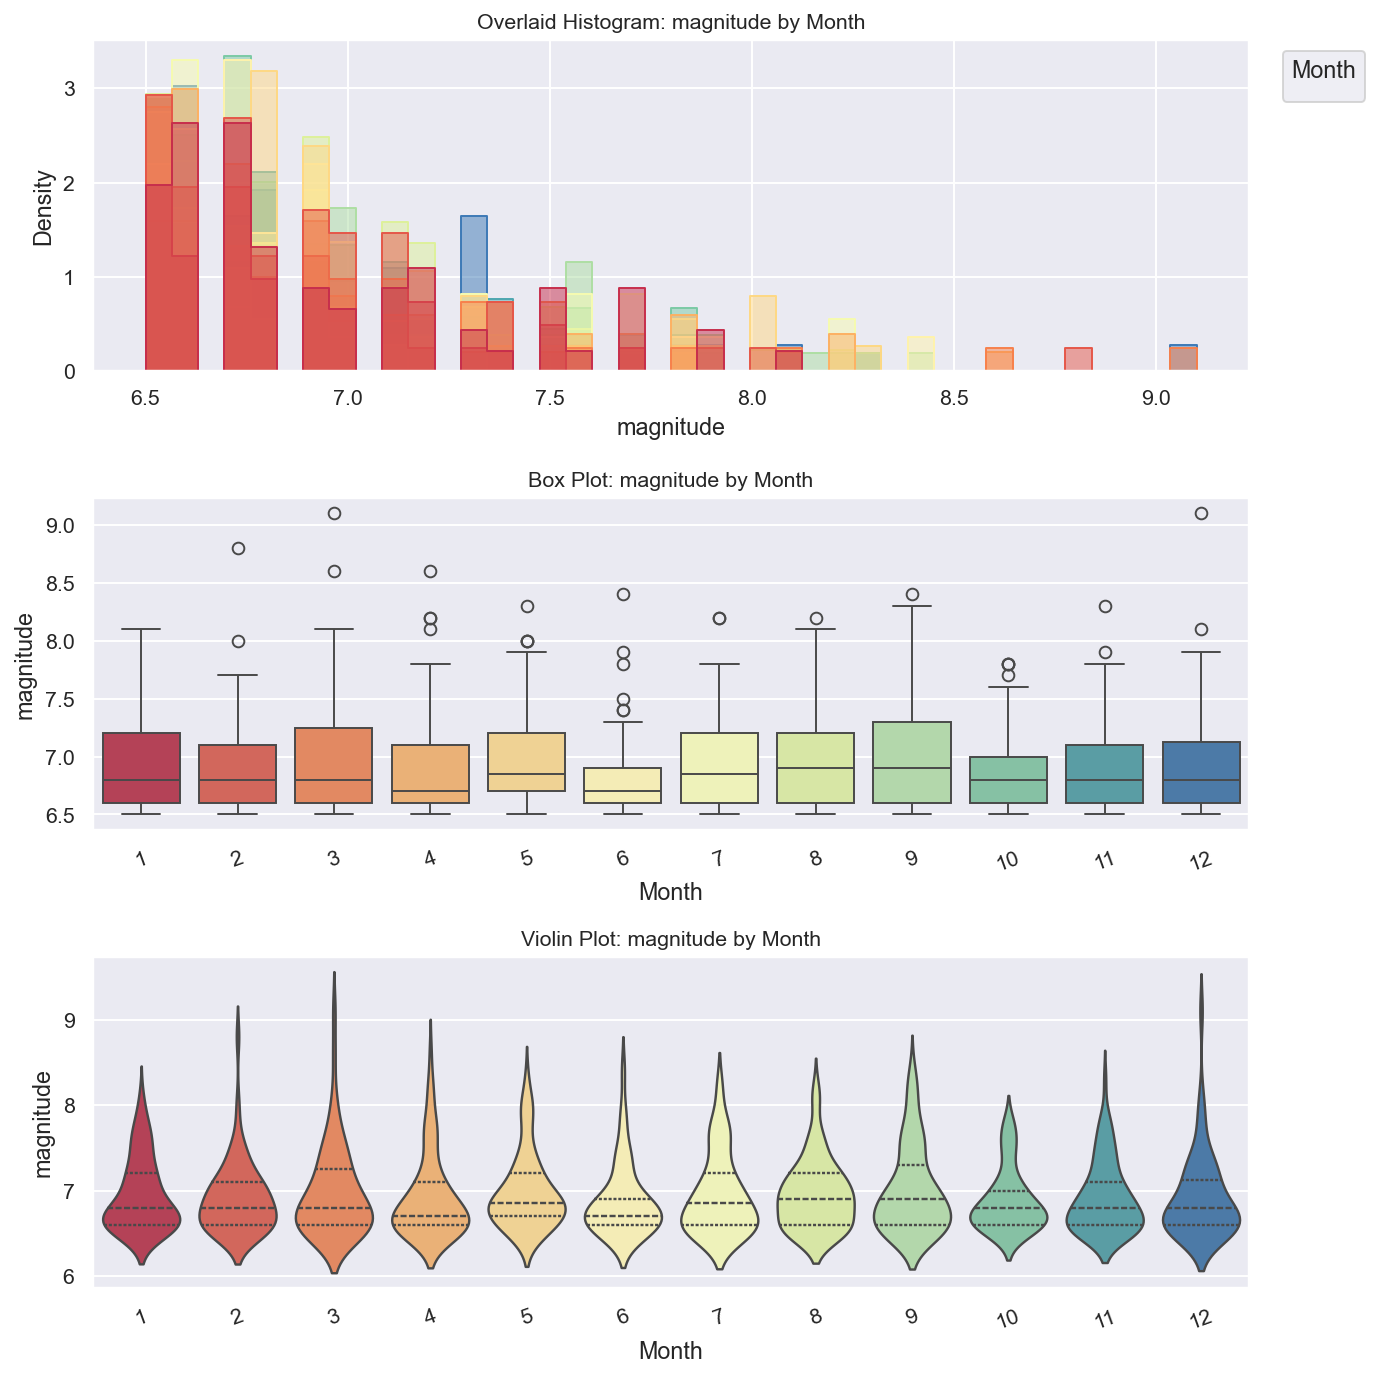

In [14]:
# === Bivariate Visualization with Improved Color Layers ===

# Choose numeric and categorical-like feature
numeric_candidates = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET]
cat_candidates = cat_like_cols(df, exclude=(TARGET,), max_levels=12)

num_col = "magnitude" if "magnitude" in numeric_candidates else numeric_candidates[0]

if len(cat_candidates) > 0:
    cat_col = "Month" if "Month" in cat_candidates else cat_candidates[0]
else:
    # fallback engineered bins
    if "depth" in df.columns:
        bins = [0, 30, 70, np.inf]
        labels = ["shallow(<30km)", "intermediate(30–70km)", "deep(≥70km)"]
        df["_depth_bin"] = pd.cut(df["depth"], bins=bins, labels=labels, include_lowest=True)
        cat_col = "_depth_bin"
    else:
        df["_num_bin"] = pd.qcut(df[num_col], q=4, duplicates="drop")
        cat_col = "_num_bin"

# improved color palette
palette = sns.color_palette("Spectral", n_colors=df[cat_col].nunique())

# Figure with three rows
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# 1) Overlaid histogram — use transparency & spectral hues
sns.histplot(
    data=df, x=num_col, hue=cat_col, bins=40,
    element="step", stat="density", common_norm=False, alpha=0.5,
    palette=palette, ax=axes[0]
)
axes[0].set_title(f"Overlaid Histogram: {num_col} by {cat_col}", fontsize=11)
axes[0].legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Box plot — consistent palette
sns.boxplot(data=df, x=cat_col, y=num_col, palette=palette, ax=axes[1])
axes[1].set_title(f"Box Plot: {num_col} by {cat_col}", fontsize=11)
axes[1].tick_params(axis="x", rotation=20)

# 3) Violin plot — smoother color layers
sns.violinplot(data=df, x=cat_col, y=num_col, inner="quartile", palette=palette, ax=axes[2])
axes[2].set_title(f"Violin Plot: {num_col} by {cat_col}", fontsize=11)
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()

# === Save to graph folder ===
graph_dir = "graph"
os.makedirs(graph_dir, exist_ok=True)

save_path = os.path.join(graph_dir, f"{num_col}_by_{cat_col}_bivariate.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Figure saved to: {save_path}")

plt.show()

### Interpretation

**Overlaid Histogram**  
- Magnitude distributions across months are broadly similar, concentrated between **6.5–7.5**.  
- The spectral palette and transparency clarify overlaps: no single month shows a distinct shift, implying **no strong seasonal variation** in magnitude.

**Box Plot**  
- Median and interquartile ranges are consistent across months, reinforcing the lack of seasonal pattern.  
- Occasional high outliers (e.g., months 3, 9, 12) correspond to rare large-magnitude events, likely due to sampling rather than true seasonality.

**Violin Plot**  
- Density shapes confirm a **single dominant magnitude cluster** with minor tails extending above 8.0.  
- Overall, magnitude is stable over time; **month is not a discriminative factor** for earthquake size.

**Conclusion**  
Across all three visualizations, the data suggest that **magnitude variation is independent of month**, supporting the idea that seismic intensity is geophysical rather than seasonal.  
Future analysis may focus on **depth** and **geographic factors**, which exhibit stronger structure than temporal ones.

## Feature Engineering


In [15]:
# !pip install cartopy geopandas shapely pyproj

In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
from pyproj import CRS
import cartopy.feature as cfeature
from cartopy.io import shapereader as shpreader

# 1) Load coastline and land polygons from Natural Earth (10m resolution)
def load_coastline_and_land():
    # Load coastline (as LineString / MultiLineString)
    coast_rec = shpreader.natural_earth(resolution='10m', category='physical', name='coastline')
    coast_gdf = gpd.read_file(coast_rec).to_crs("EPSG:4326")
    coastline_union = coast_gdf.unary_union

    # Load land polygons (as Polygon / MultiPolygon) for land mask
    land_rec = shpreader.natural_earth(resolution='10m', category='physical', name='land')
    land_gdf = gpd.read_file(land_rec).to_crs("EPSG:4326")
    land_union = land_gdf.unary_union
    land_prep = prep(land_union)  # Prepared geometry for faster "contains" checks

    return coastline_union, land_prep

coastline_union, land_prep = load_coastline_and_land()

# Create an Azimuthal Equidistant local projection (distance in meters)
def aeqd_crs(lat, lon):
    return CRS.from_proj4(
        f"+proj=aeqd +lat_0={lat} +lon_0={lon} +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

# 2) Main function: add three columns to df
def add_coast_distance_features_online(df, lat_col="latitude", lon_col="longitude",
                                       bin_deg=5, signed_extra=True):
    """
    Adds:
      - is_ocean: 1 if ocean, 0 if land
      - dist_to_coast_km: distance to nearest coastline (km); 0 for land
      - dist_to_coast_signed_km: +distance for ocean, -distance for land
    """
    out = df.copy()
    assert lat_col in out.columns and lon_col in out.columns, "Latitude/longitude columns missing."

    lats = out[lat_col].astype(float).to_numpy()
    lons = out[lon_col].astype(float).to_numpy()

    # Determine whether each point is on land
    is_land = np.array([land_prep.contains(Point(lon, lat)) for lat, lon in zip(lats, lons)], dtype=bool)
    is_ocean = ~is_land
    out["is_ocean"] = is_ocean.astype(int)

    # Bin points in 5°×5° grid to reduce repeated projection cost
    lat_bin = np.floor(lats / bin_deg).astype(int)
    lon_bin = np.floor(lons / bin_deg).astype(int)
    buckets = pd.Series(list(zip(lat_bin, lon_bin))).astype("category")

    # Prepare coastline GeoSeries for projection
    coast_gs = gpd.GeoSeries([coastline_union], crs="EPSG:4326")

    dist_signed_km = np.full_like(lats, np.nan, dtype=float)

    for b in np.unique(buckets):
        idx = np.where(buckets == b)[0]
        if len(idx) == 0:
            continue

        lat0 = float(np.mean(lats[idx]))
        lon0 = float(np.mean(lons[idx]))
        local_crs = aeqd_crs(lat0, lon0)

        # Points → local projection
        pts_ll = gpd.GeoSeries([Point(lons[i], lats[i]) for i in idx], crs="EPSG:4326")
        pts_loc = pts_ll.to_crs(local_crs)

        # Coastline → local projection
        coast_loc = coast_gs.to_crs(local_crs).iloc[0]

        # Euclidean distances in meters
        dists_m = np.array([geom.distance(coast_loc) for geom in pts_loc.geometry], dtype=float)
        dists_km = dists_m / 1000.0

        # Signed: positive for ocean, negative for land
        dist_signed_km[idx] = np.where(is_ocean[idx], dists_km, -dists_km)

    if signed_extra:
        out["dist_to_coast_signed_km"] = dist_signed_km
        out["dist_to_coast_km"] = np.where(out["is_ocean"] == 1, np.abs(dist_signed_km), 0.0)
    else:
        out["dist_to_coast_km"] = np.where(is_ocean, np.abs(dist_signed_km), 0.0)

    # Basic sanity checks
    assert (out["dist_to_coast_km"] >= 0).all()
    assert np.allclose(out.loc[out["is_ocean"] == 0, "dist_to_coast_km"], 0.0)

    return out

# 3) Apply to df BEFORE encoding/scatter matrix/split
df = add_coast_distance_features_online(df, lat_col="latitude", lon_col="longitude",
                                        bin_deg=5, signed_extra=True)

print("✅ Added columns:", [c for c in ["is_ocean","dist_to_coast_km","dist_to_coast_signed_km"] if c in df.columns])
print(df[["latitude","longitude","is_ocean","dist_to_coast_km","dist_to_coast_signed_km"]].head())

✅ Added columns: ['is_ocean', 'dist_to_coast_km', 'dist_to_coast_signed_km']
   latitude  longitude  is_ocean  dist_to_coast_km  dist_to_coast_signed_km
0   -9.7963    159.596         1         17.124763                17.124763
1   -4.9559    100.738         1        156.589124               156.589124
2  -20.0508   -178.346         1         26.462106                26.462106
3  -19.2918   -172.129         1        202.022305               202.022305
4  -25.5948    178.278         1        547.796036               547.796036


In [17]:
# === Sanity checks for coastline distance feature ===

# 1) Near-coast ocean samples (<20 km)
near_coast_ocean = (
    df.query("is_ocean == 1")
      .nsmallest(5, "dist_to_coast_km")[["latitude","longitude","dist_to_coast_km","dist_to_coast_signed_km"]]
)
print("\n🌊 Near-coast ocean samples (should be small positive distances):")
print(near_coast_ocean)

# 2) Open-ocean samples (hundreds to >1000 km)
far_ocean = (
    df.query("is_ocean == 1")
      .nlargest(5, "dist_to_coast_km")[["latitude","longitude","dist_to_coast_km"]]
)
print("\n🌐 Open-ocean samples (should be large positive distances):")
print(far_ocean)

# 3) Inland samples (on land: dist_to_coast_km = 0, signed negative)
#    Use absolute value to find the deepest inland points
inland = (
    df.query("is_ocean == 0")
      .assign(abs_signed=lambda d: d["dist_to_coast_signed_km"].abs())
      .nlargest(5, "abs_signed")[["latitude","longitude","dist_to_coast_km","dist_to_coast_signed_km"]]
)
print("\n🏞️ Inland samples (unsigned=0, signed negative with large absolute values):")
print(inland)

# 4) Sanity: ocean should have positive signed distances; land should have negative
if "dist_to_coast_signed_km" in df.columns:
    ok_sea = (df.loc[df["is_ocean"]==1, "dist_to_coast_signed_km"] >= 0).all()
    ok_land = (df.loc[df["is_ocean"]==0, "dist_to_coast_signed_km"] <= 0).all()
    print(f"\nSanity check → Ocean positive? {ok_sea} | Land negative? {ok_land}")


🌊 Near-coast ocean samples (should be small positive distances):
     latitude  longitude  dist_to_coast_km  dist_to_coast_signed_km
228    5.2834    96.1678          0.806761                 0.806761
218  -10.3506   161.3350          0.819741                 0.819741
569   -2.4860    99.9720          0.830993                 0.830993
618   19.8770  -155.9350          1.176225                 1.176225
189    9.5147   -84.4865          1.403907                 1.403907

🌐 Open-ocean samples (should be large positive distances):
     latitude  longitude  dist_to_coast_km
389   10.7010   -42.5940       1195.451331
257   -4.9521    94.3299        621.300306
160  -25.4150   178.1990        549.464331
4    -25.5948   178.2780        547.796036
137  -43.1219    42.3568        519.926829

🏞️ Inland samples (unsigned=0, signed negative with large absolute values):
     latitude  longitude  dist_to_coast_km  dist_to_coast_signed_km
710   50.0380     87.813               0.0             -2012.56

Saved: graph/fig1_kde_signed.png


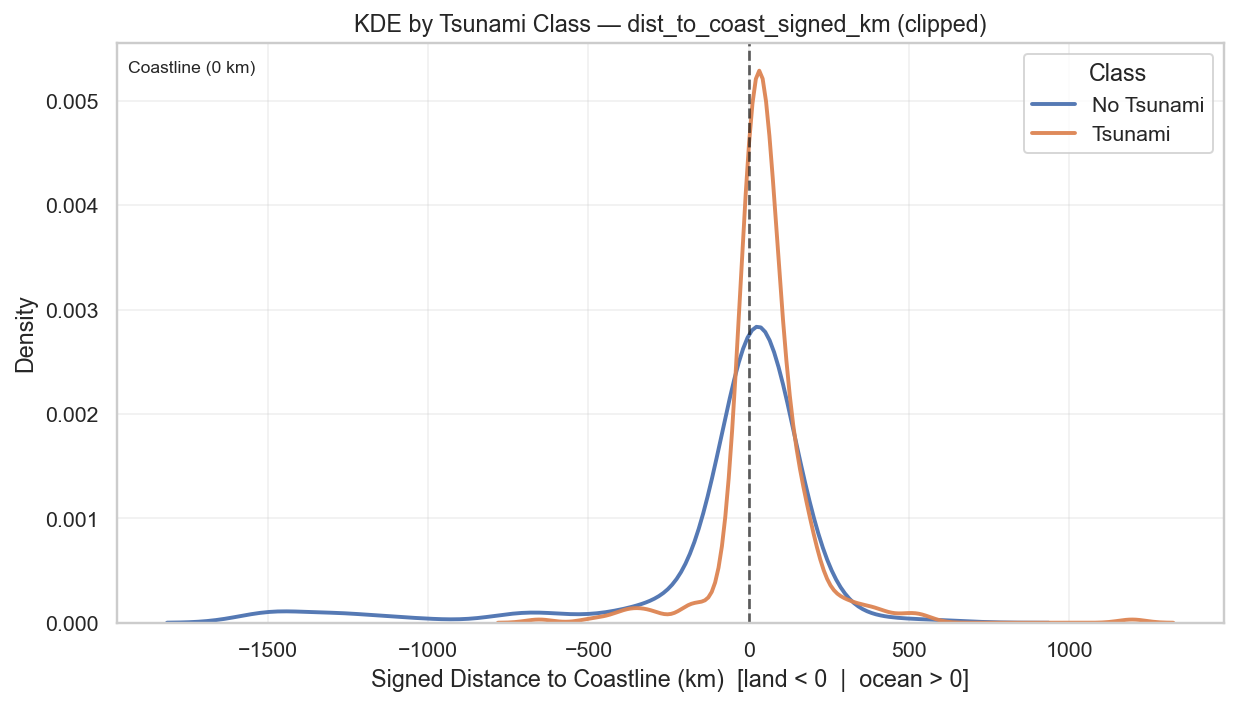

Saved: graph/fig2_rate_signed.png


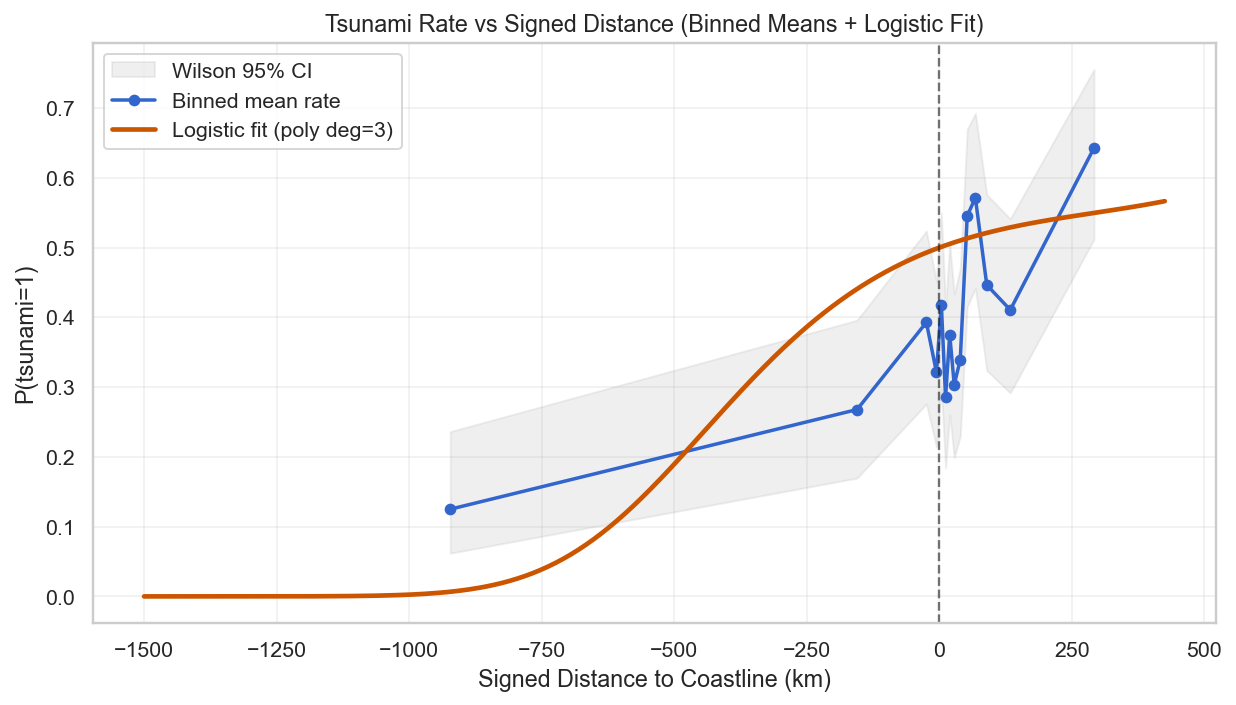

Saved: graph/fig3_ocean_dist.png


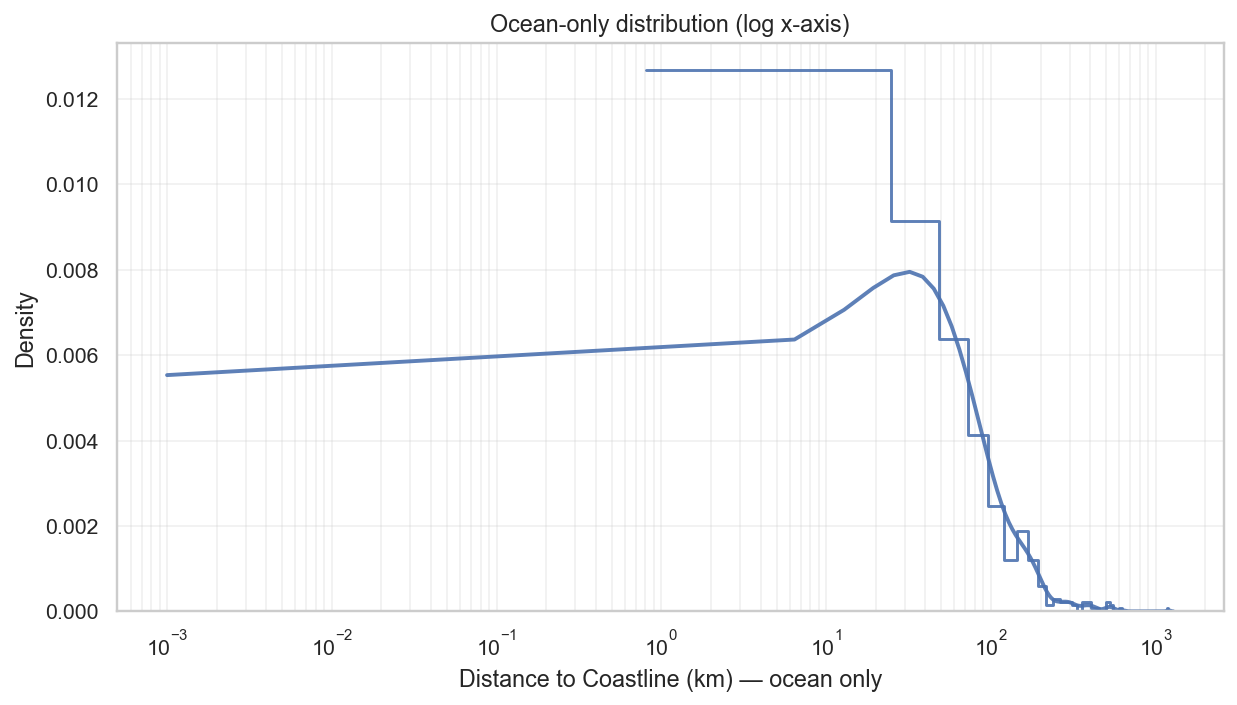

Saved: graph/fig3_ocean_rate.png


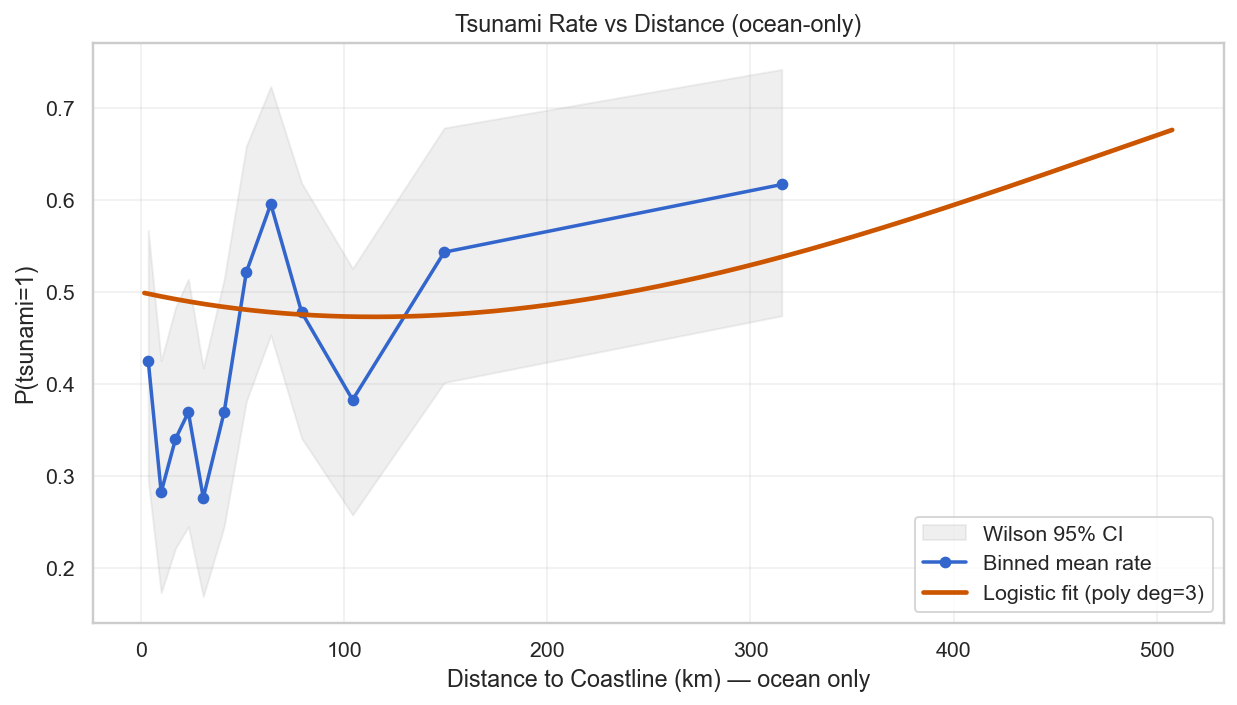

Saved: graph/fig4_violin_boxen_signed.png


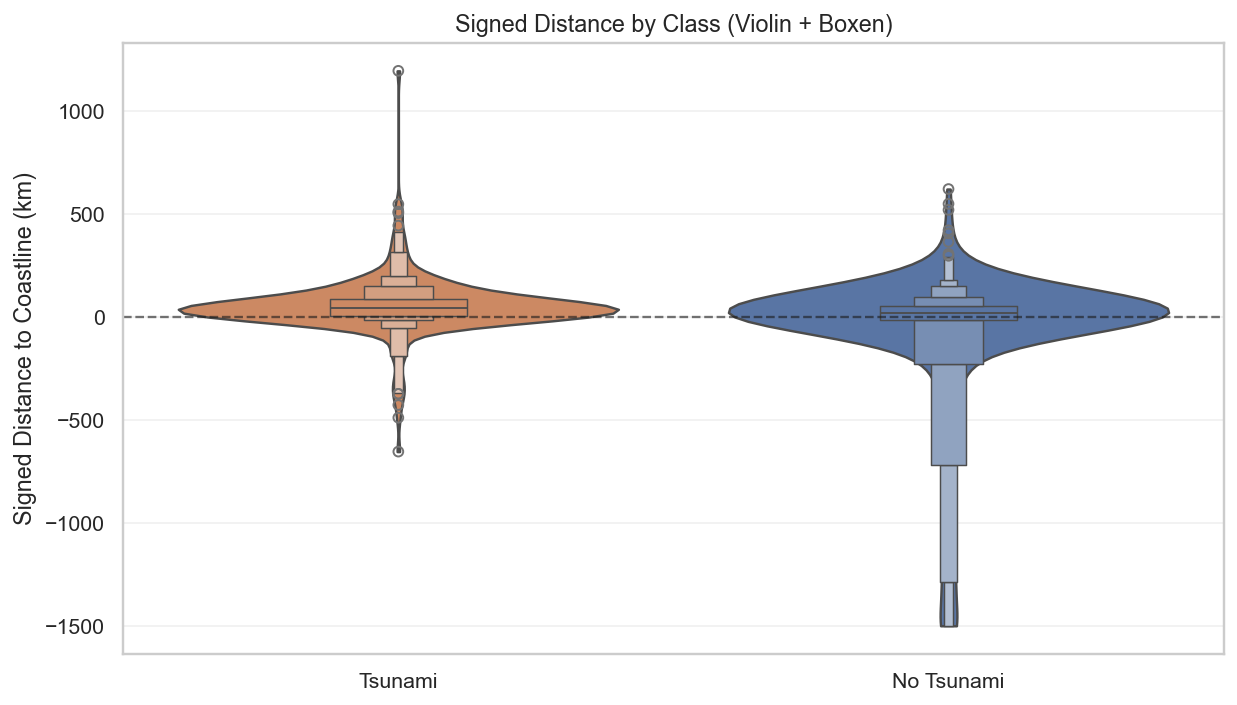

In [18]:
# === Improved visualization (uniform figure size + fixed palette syntax) ===
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

assert TARGET in df.columns
assert {"dist_to_coast_km", "dist_to_coast_signed_km", "is_ocean"} <= set(df.columns)

sns.set(context="notebook", style="whitegrid")
palette_num = {0: "#4C72B0", 1: "#DD8452"}                 # numeric class palette
palette_cls = {"No Tsunami": "#4C72B0", "Tsunami": "#DD8452"}  # string class palette
FIGSIZE = (9, 5.2)
os.makedirs("graph", exist_ok=True)

# ---------------- helper functions ----------------
def wilson_interval(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2/(2*n)) / denom
    margin = z * np.sqrt(phat*(1-phat)/n + z**2/(4*n**2)) / denom
    return center - margin, center + margin

def binned_wilson(x, y, bins=15, clip=None, qcut=True):
    s = pd.Series(x)
    if clip is not None:
        s = s.clip(lower=clip[0], upper=clip[1])
    df_xy = pd.DataFrame({"x": s.values, "y": np.asarray(y)}).dropna()
    cats = pd.qcut(df_xy["x"], q=bins, duplicates="drop") if qcut else pd.cut(df_xy["x"], bins=bins)
    grp = df_xy.groupby(cats)
    xc = grp["x"].mean().to_numpy()
    n = grp["y"].size().to_numpy()
    k = grp["y"].sum().to_numpy()
    rate = np.divide(k, n, out=np.full_like(k, np.nan, dtype=float), where=n > 0)
    ci = np.array([wilson_interval(int(ki), int(ni)) for ki, ni in zip(k, n)])
    lo, hi = ci[:, 0], ci[:, 1]
    out = pd.DataFrame({"x": xc, "rate": rate, "n": n, "lo": lo, "hi": hi}).dropna()
    return out.sort_values("x")

def logistic_curve(x, y, degree=3, grid=None):
    X = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel().astype(int)
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LogisticRegression(max_iter=2000, C=10.0, solver="lbfgs"),
    )
    model.fit(X, y)
    gx = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), 400) if grid is None else np.asarray(grid)
    gy = model.predict_proba(gx.reshape(-1, 1))[:, 1]
    return gx, gy

# ---------------- data prep ----------------
plot_df = df[[TARGET, "dist_to_coast_signed_km", "dist_to_coast_km", "is_ocean"]].dropna().copy()
clip_signed = (-1500, 1500)
plot_df["dist_to_coast_signed_km_clip"] = plot_df["dist_to_coast_signed_km"].clip(*clip_signed)

# ---------------- Fig1: KDE on signed distance ----------------
fig, ax = plt.subplots(figsize=FIGSIZE)
for t, lab in [(0, "No Tsunami"), (1, "Tsunami")]:
    sns.kdeplot(
        plot_df.loc[plot_df[TARGET] == t, "dist_to_coast_signed_km_clip"],
        ax=ax, lw=2, alpha=0.95, label=lab, color=palette_num[t], bw_method=0.3
    )
ax.axvline(0.0, ls="--", lw=1.4, color="k", alpha=0.7)
ax.text(0.01, 0.97, "Coastline (0 km)", transform=ax.transAxes, ha="left", va="top", fontsize=9)
ax.set_xlabel("Signed Distance to Coastline (km)  [land < 0  |  ocean > 0]")
ax.set_ylabel("Density")
ax.set_title("KDE by Tsunami Class — dist_to_coast_signed_km (clipped)")
ax.legend(title="Class", frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
p1 = "graph/fig1_kde_signed.png"
plt.savefig(p1, dpi=220, bbox_inches="tight"); print(f"Saved: {p1}")
plt.show()

# ---------------- Fig2: Binned rate vs signed distance ----------------
bins_signed = 14
df_b = binned_wilson(plot_df["dist_to_coast_signed_km"], plot_df[TARGET],
                     bins=bins_signed, clip=clip_signed, qcut=True)
gx, gy = logistic_curve(plot_df["dist_to_coast_signed_km"].clip(*clip_signed),
                        plot_df[TARGET], degree=3)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.fill_between(df_b["x"], df_b["lo"], df_b["hi"], alpha=0.15, color="#999999", label="Wilson 95% CI")
ax.plot(df_b["x"], df_b["rate"], marker="o", lw=1.8, ms=5, label="Binned mean rate", color="#3366CC")
ax.plot(gx, gy, lw=2.4, color="#CC5500", label="Logistic fit (poly deg=3)")
ax.axvline(0.0, ls="--", lw=1.2, color="k", alpha=0.6)
ax.set_xlabel("Signed Distance to Coastline (km)")
ax.set_ylabel(f"P({TARGET}=1)")
ax.set_title("Tsunami Rate vs Signed Distance (Binned Means + Logistic Fit)")
ax.legend(frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
p2 = "graph/fig2_rate_signed.png"
plt.savefig(p2, dpi=220, bbox_inches="tight"); print(f"Saved: {p2}")
plt.show()

# ---------------- Fig3A: Ocean-only distribution ----------------
ocean = plot_df.query("is_ocean == 1").copy()
eps = 1e-3
ocean["km_pos"] = ocean["dist_to_coast_km"].clip(lower=eps)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(ocean["km_pos"], bins=50, stat="density", element="step",
             fill=False, color="#4C72B0", ax=ax, alpha=0.9)
sns.kdeplot(ocean["km_pos"], ax=ax, lw=2, alpha=0.9, color="#4C72B0", clip=(eps, None))
ax.set_xscale("log")
ax.set_xlabel("Distance to Coastline (km) — ocean only")
ax.set_ylabel("Density")
ax.set_title("Ocean-only distribution (log x-axis)")
ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
p3a = "graph/fig3_ocean_dist.png"
plt.savefig(p3a, dpi=220, bbox_inches="tight"); print(f"Saved: {p3a}")
plt.show()

# ---------------- Fig3B: Ocean-only rate vs distance ----------------
df_km = binned_wilson(ocean["dist_to_coast_km"], ocean[TARGET], bins=12, qcut=True)
gx2, gy2 = logistic_curve(ocean["dist_to_coast_km"], ocean[TARGET], degree=3)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.fill_between(df_km["x"], df_km["lo"], df_km["hi"], alpha=0.15, color="#999999", label="Wilson 95% CI")
ax.plot(df_km["x"], df_km["rate"], marker="o", lw=1.8, ms=5, label="Binned mean rate", color="#3366CC")
ax.plot(gx2, gy2, lw=2.4, color="#CC5500", label="Logistic fit (poly deg=3)")
ax.set_xlabel("Distance to Coastline (km) — ocean only")
ax.set_ylabel(f"P({TARGET}=1)")
ax.set_title("Tsunami Rate vs Distance (ocean-only)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
p3b = "graph/fig3_ocean_rate.png"
plt.savefig(p3b, dpi=220, bbox_inches="tight"); print(f"Saved: {p3b}")
plt.show()

# ---------------- Fig4: Violin + boxen (palette fix) ----------------
tmp = plot_df.copy()
tmp["cls"] = tmp[TARGET].map({0: "No Tsunami", 1: "Tsunami"})
tmp["signed_clip"] = tmp["dist_to_coast_signed_km"].clip(*clip_signed)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.violinplot(data=tmp, x="cls", y="signed_clip", inner=None, cut=0, palette=palette_cls, ax=ax)
sns.boxenplot(data=tmp, x="cls", y="signed_clip", width=0.25, palette=palette_cls, ax=ax)
ax.axhline(0.0, ls="--", lw=1.2, color="k", alpha=0.6)
ax.set_xlabel("")
ax.set_ylabel("Signed Distance to Coastline (km)")
ax.set_title("Signed Distance by Class (Violin + Boxen)")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
p4 = "graph/fig4_violin_boxen_signed.png"
plt.savefig(p4, dpi=220, bbox_inches="tight"); print(f"Saved: {p4}")
plt.show()

### Relationship between Tsunami Occurrence and Distance to Coastline

**Figure 1 – KDE by Tsunami Class (Signed Distance)**
- 0 km marks the coastline (land < 0, ocean > 0).  
- Tsunami events (orange) peak near the coast, slightly on the ocean side.  
- Non-tsunami events (blue) peak inland.  
→ *Tsunamis are primarily triggered by coastal or nearshore earthquakes.*

---

**Figure 2 – Binned Tsunami Rate vs Signed Distance**
- Blue dots show binned average tsunami probability with 95% Wilson CI.  
- Orange curve: polynomial logistic regression fit.  
- Probability rises sharply from inland to near-coast and levels off offshore.  
→ *Closer or offshore earthquakes have a higher tsunami likelihood.*

---

**Figure 3A – Ocean-only Distribution (log scale)**
- Only oceanic events (is_ocean=1) are shown.  
- Most occur within tens of kilometers from the coast; deep-ocean quakes are rare.  
→ *Nearshore oceanic earthquakes dominate the sample.*

---

**Figure 3B – Ocean-only Tsunami Rate vs Distance**
- Even among oceanic events, those closer to shore have a higher tsunami rate.  
→ *Proximity to the coastline remains predictive of tsunami generation.*

---

**Figure 4 – Signed Distance by Class (Violin + Boxen)**
- Tsunami events (orange) cluster around 0 km; non-tsunami (blue) extend inland.  
→ *A clear spatial separation between the two classes.*

### Scatter Matrix for Key Numeric Features

✅ Scatter matrix using columns: ['magnitude', 'depth', 'sig', 'nst', 'dmin', 'gap', 'dist_to_coast_km', 'dist_to_coast_signed_km']
📁 Figure saved to: graph/scatter_matrix_numeric_features.png


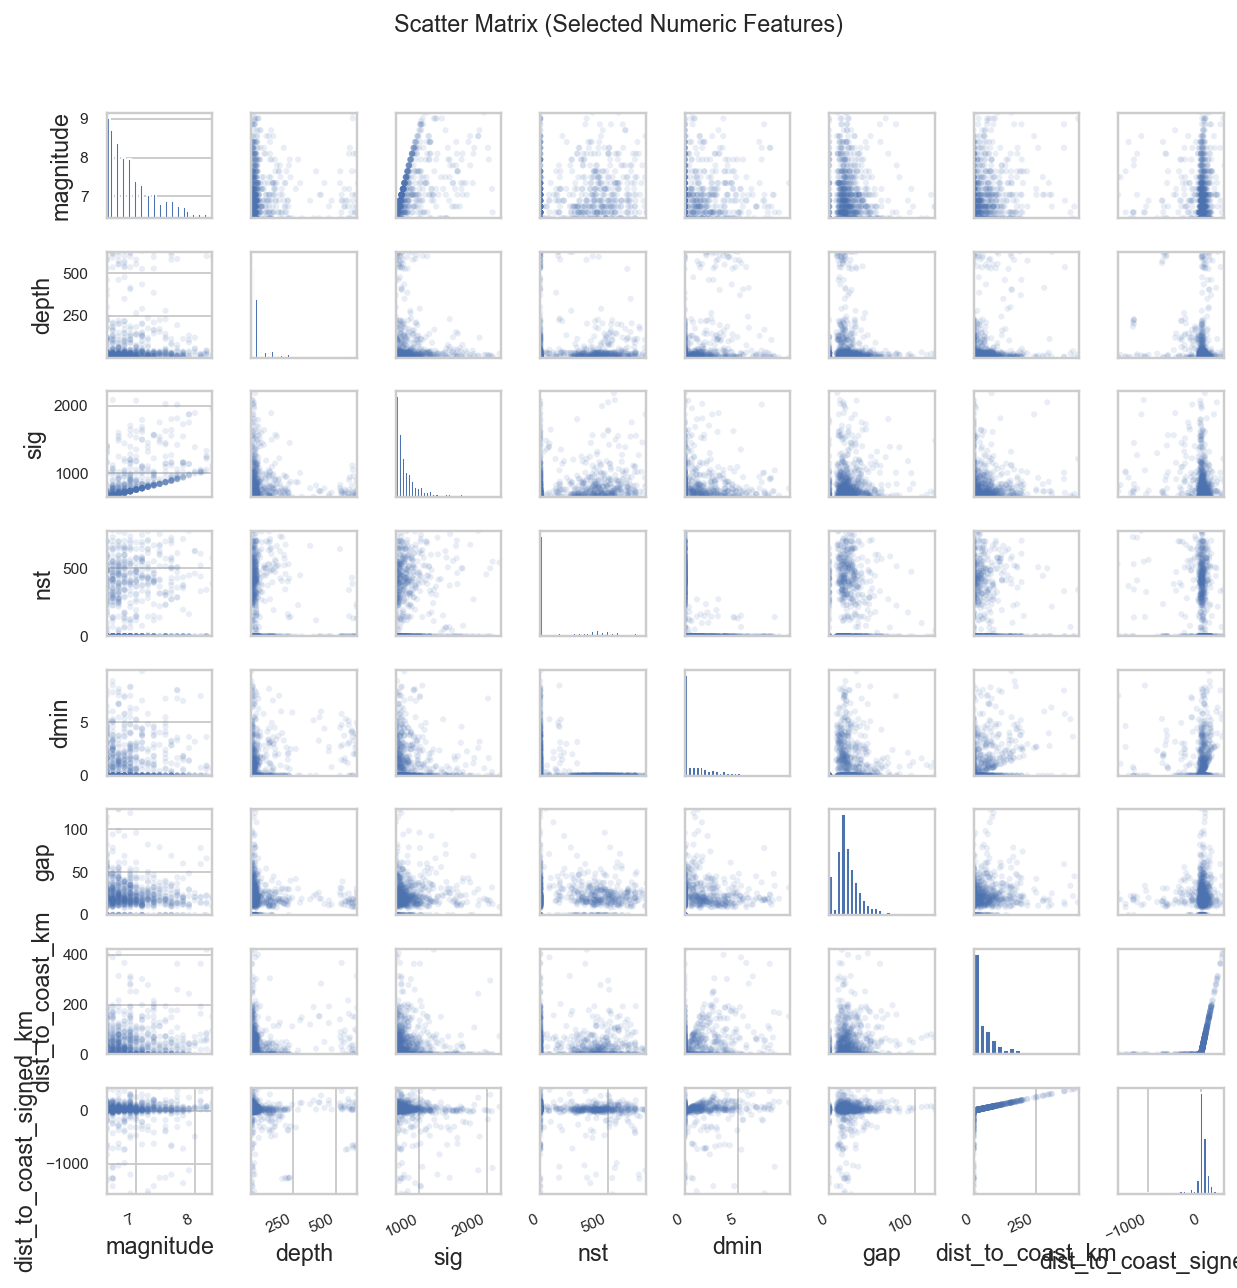

In [19]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- auto-select numeric columns, exclude target ---
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET]

# pick representative numeric features (limit for clarity)
cand = [c for c in [
    "magnitude", "depth", "sig", "nst", "dmin", "gap",
    "dist_to_coast_km", "dist_to_coast_signed_km"
] if c in num_cols]
if len(cand) < 2:
    cand = num_cols[:5]  # fallback  

if len(cand) >= 2:
    print(f"✅ Scatter matrix using columns: {cand}")
    plot_df = df[cand].dropna()

    # optional sampling for clarity
    if len(plot_df) > 10_000:
        plot_df = plot_df.sample(10_000, random_state=7)

    # axis limits for display consistency (1–99 percentile)
    lims = {c: tuple(np.nanpercentile(plot_df[c], [1, 99])) for c in cand}

    axs = pd.plotting.scatter_matrix(
        plot_df,
        figsize=(9, 9),
        marker='o',
        s=10,
        alpha=.12,
        color="#4C72B0",
        diagonal='hist',
        hist_kwds={'bins': 50}
    )

    n = len(cand)
    for i in range(n):
        for j in range(n):
            ax = axs[i, j]
            ax.tick_params(labelsize=8)
            if i == n - 1:
                for lbl in ax.get_xticklabels():
                    lbl.set_rotation(25)
                    lbl.set_horizontalalignment("right")
                    lbl.set_fontsize(8)
            else:
                ax.set_xticklabels([])

            if j != i:
                ax.set_xlim(*lims[cand[j]])
                ax.set_ylim(*lims[cand[i]])
            else:
                ax.set_xlim(*lims[cand[j]])

    plt.suptitle("Scatter Matrix (Selected Numeric Features)", y=1.02, fontsize=12)
    plt.tight_layout()

    # --- save to graph folder ---
    os.makedirs("graph", exist_ok=True)
    save_path = "graph/scatter_matrix_numeric_features.png"
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    print(f"📁 Figure saved to: {save_path}")

    plt.show()
else:
    print("Not enough numeric columns for a scatter matrix.")

### Interpretation: Scatter Matrix

- `magnitude` and `sig` rise together — larger quakes have higher hazard scores.  
- `depth` shows no link with magnitude → mostly independent.  
- `nst`, `dmin`, `gap` reflect network quality: fewer stations → larger distance/gap.  
- Most variables are right-skewed → use log or robust scaling.  

**Takeaway:**  
Two feature clusters emerge:  
1. **Seismic intensity** (`magnitude`, `sig`)  
2. **Observation quality** (`nst`, `dmin`, `gap`)  
→ non-linear models handle them best.

### Encoding Pipeline Design

**Feature Groups**
- **Physics:** `['magnitude', 'sig', 'depth']`  
- **Network-quality (optional):** `['nst','dmin','gap']` — excluded by default (toggleable)  
- **Ordinal:** `['cdi','mmi']` — numeric 0–9, treated as continuous  
- **Temporal:**  
  - `Month` → cyclical encoding (`sin`, `cos`)  
  - `Year` → excluded (used only for time validation)  
- **Coastline proximity:**  
  - **`is_ocean`** — only categorical feature, encoded via OneHotEncoder  
  - **Distance variable (choose one):**
    - `dist_to_coast_signed_km` — negative for inland, positive for ocean (recommended for linear or NN models)  
    - `dist_to_coast_km` — zero for land, positive for ocean (recommended for tree-based models)

**Processing Steps**
- `sig`, `depth` → `log1p` transform + standardization  
- All other numeric features → `StandardScaler`  
- `Month` → cyclical (`sin`, `cos`) + standardization  
- `is_ocean` → `OneHotEncoder(drop='if_binary')` → single binary column  
- `ColumnTransformer` combines these pipelines into one unified encoder.  

In [20]:
# =========================
# Build TWO encoders: LINEAR/NN and TREE
# (design only; do NOT fit/transform here)
# =========================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder

TARGET = "tsunami"

# ------------- helpers -------------
def month_cyc_transform(X):
    m = np.asarray(X, dtype=float).ravel()
    theta = 2 * np.pi * (m / 12.0)
    return np.c_[np.sin(theta), np.cos(theta)]

month_cyc = FunctionTransformer(
    month_cyc_transform,
    validate=False,
    feature_names_out=lambda t, f: np.array(["Month_sin","Month_cos"])
)

def print_encoder_summary(name, encoder):
    print(f"\n=== {name} — Encoder Summary ===")
    for nm, trans, cols in encoder.transformers:
        print(f" - {nm:<15} → {len(cols)} column(s): {cols}")
    print("="*30 + "\n")

# ------------- shared groups (present in df) -------------
physics_feats   = [c for c in ['magnitude','sig','depth'] if c in df.columns]
ordinal_feats   = [c for c in ['cdi','mmi'] if c in df.columns]
network_feats   = [c for c in ['nst','dmin','gap'] if c in df.columns]  # optional, off by default
has_month       = 'Month' in df.columns
has_is_ocean    = 'is_ocean' in df.columns
has_signed      = 'dist_to_coast_signed_km' in df.columns
has_unsigned    = 'dist_to_coast_km' in df.columns

# =========================================================
# A) LINEAR / NN ENCODER (scaled + log1p + signed distance)
# =========================================================
# variables
LIN_NUM_HEAVY = [c for c in ['sig','depth'] if c in df.columns]  # log1p + scale
LIN_NUM_STD   = [c for c in physics_feats if c not in LIN_NUM_HEAVY]
LIN_NUM_STD  += [c for c in ordinal_feats]
if has_signed:   LIN_NUM_STD += ['dist_to_coast_signed_km']    # signed distance
elif has_unsigned: LIN_NUM_STD += ['dist_to_coast_km']         # fallback if signed missing

LIN_CAT_OHE  = ['is_ocean'] if has_is_ocean else []            # only is_ocean

# pipelines
lin_pipe_std   = Pipeline([("scaler", StandardScaler())])
# Preserve feature names across log1p so ColumnTransformer can expose names
lin_pipe_heavy = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])
lin_pipe_month = Pipeline([("cyc", month_cyc), ("scaler", StandardScaler())])
lin_pipe_ohe   = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))]) if LIN_CAT_OHE else None

# column transformer
lin_transformers = []
if LIN_NUM_STD:   lin_transformers.append(("num_std",   lin_pipe_std,   LIN_NUM_STD))
if LIN_NUM_HEAVY: lin_transformers.append(("num_heavy", lin_pipe_heavy, LIN_NUM_HEAVY))
if has_month:     lin_transformers.append(("month",     lin_pipe_month, ['Month']))
if LIN_CAT_OHE:   lin_transformers.append(("is_ocean_ohe", lin_pipe_ohe, LIN_CAT_OHE))

linear_encoder = ColumnTransformer(
    transformers=lin_transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

# feature list (for splitting later)
linear_feature_cols = LIN_NUM_STD + LIN_NUM_HEAVY + (['Month'] if has_month else []) + LIN_CAT_OHE

# print variables
print(">>> LINEAR/NN variables")
print("NUM_STD:", LIN_NUM_STD)
print("NUM_HEAVY (log1p):", LIN_NUM_HEAVY)
print("CAT_OHE:", LIN_CAT_OHE)
print_encoder_summary("LINEAR/NN", linear_encoder)

# ===============================================
# B) TREE ENCODER (no scaling, no log1p, unsigned)
# ===============================================
# variables
TREE_NUM_PLAIN = []
# physics straight through
TREE_NUM_PLAIN += physics_feats
# ordinal straight through
TREE_NUM_PLAIN += ordinal_feats
# coastline: prefer unsigned + is_ocean
if has_unsigned:
    TREE_NUM_PLAIN += ['dist_to_coast_km']
elif has_signed:
    # fallback: absolute of signed if unsigned missing
    # (we won't compute here; assume you have dist_to_coast_km; otherwise keep signed)
    TREE_NUM_PLAIN += ['dist_to_coast_signed_km']
TREE_CAT_OHE = ['is_ocean'] if has_is_ocean else []

# remove duplicates while preserving order
def _dedup(seq): 
    seen=set(); out=[]
    for x in seq:
        if x not in seen:
            seen.add(x); out.append(x)
    return out
TREE_NUM_PLAIN = _dedup(TREE_NUM_PLAIN)

# pipelines (passthrough)
tree_pipe_month = Pipeline([("cyc", month_cyc)])  # no scaler for trees
tree_pipe_ohe   = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))]) if TREE_CAT_OHE else None

tree_transformers = []
if TREE_NUM_PLAIN: tree_transformers.append(("num_plain", "passthrough", TREE_NUM_PLAIN))
if has_month:      tree_transformers.append(("month",     tree_pipe_month, ['Month']))
if TREE_CAT_OHE:   tree_transformers.append(("is_ocean_ohe", tree_pipe_ohe, TREE_CAT_OHE))

tree_encoder = ColumnTransformer(
    transformers=tree_transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

tree_feature_cols = TREE_NUM_PLAIN + (['Month'] if has_month else []) + TREE_CAT_OHE

# print variables
print(">>> TREE variables")
print("NUM_PLAIN:", TREE_NUM_PLAIN)
print("CAT_OHE:", TREE_CAT_OHE)
print_encoder_summary("TREE", tree_encoder)


>>> LINEAR/NN variables
NUM_STD: ['magnitude', 'cdi', 'mmi', 'dist_to_coast_signed_km']
NUM_HEAVY (log1p): ['sig', 'depth']
CAT_OHE: ['is_ocean']

=== LINEAR/NN — Encoder Summary ===
 - num_std         → 4 column(s): ['magnitude', 'cdi', 'mmi', 'dist_to_coast_signed_km']
 - num_heavy       → 2 column(s): ['sig', 'depth']
 - month           → 1 column(s): ['Month']
 - is_ocean_ohe    → 1 column(s): ['is_ocean']

>>> TREE variables
NUM_PLAIN: ['magnitude', 'sig', 'depth', 'cdi', 'mmi', 'dist_to_coast_km']
CAT_OHE: ['is_ocean']

=== TREE — Encoder Summary ===
 - num_plain       → 6 column(s): ['magnitude', 'sig', 'depth', 'cdi', 'mmi', 'dist_to_coast_km']
 - month           → 1 column(s): ['Month']
 - is_ocean_ohe    → 1 column(s): ['is_ocean']



## Train/Test Split

**Goal**
- Split encoded data into training and testing subsets while preserving the tsunami class balance.

**Design**
- **Stratified sampling:** maintains the same 1/0 ratio across both sets.  
- **Split ratio:** 80% training / 20% testing.  

In [21]:
# === Stratified split (by index) + fit/transform for BOTH encoders ===
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

assert TARGET in df.columns, "TARGET column missing."
y = df[TARGET].copy()

# 1) Split ON INDICES to reuse same split for both pipelines
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("✅ Stratified split complete.")
print(f"Train size: {len(idx_train)} | Test size: {len(idx_test)}")
print(f"Tsunami ratio (train): {y.loc[idx_train].mean():.3f}")
print(f"Tsunami ratio (test) : {y.loc[idx_test].mean():.3f}")

✅ Stratified split complete.
Train size: 625 | Test size: 157
Tsunami ratio (train): 0.389
Tsunami ratio (test) : 0.389


In [22]:
# 2) Prepare raw feature frames for each encoder
#    (use the feature_cols you already built when defining encoders)
# Linear/NN
X_train_lin_raw = df.loc[idx_train, linear_feature_cols].copy()
X_test_lin_raw  = df.loc[idx_test,  linear_feature_cols].copy()
y_train = y.loc[idx_train].copy()
y_test  = y.loc[idx_test].copy()

# Tree
X_train_tree_raw = df.loc[idx_train, tree_feature_cols].copy()
X_test_tree_raw  = df.loc[idx_test,  tree_feature_cols].copy()
# y_train/y_test already defined above (same indices)

# 3) Fit/transform — LINEAR/NN
X_train_lin = linear_encoder.fit_transform(X_train_lin_raw)
X_test_lin  = linear_encoder.transform(X_test_lin_raw)

print("\n[Linear/NN] Encoded shapes:")
print(f"  X_train_lin: {X_train_lin.shape} | X_test_lin: {X_test_lin.shape}")

# 4) Fit/transform — TREE
X_train_tree = tree_encoder.fit_transform(X_train_tree_raw)
X_test_tree  = tree_encoder.transform(X_test_tree_raw)

print("\n[Tree] Encoded shapes:")
print(f"  X_train_tree: {X_train_tree.shape} | X_test_tree: {X_test_tree.shape}")

# 5) (Optional) show a few encoded feature names
try:
    lin_names = linear_encoder.get_feature_names_out()
    print("\n[Linear/NN] First 20 feature names:")
    for n in lin_names[:20]: print(" -", n)
except Exception:
    pass

try:
    tree_names = tree_encoder.get_feature_names_out()
    print("\n[Tree] First 20 feature names:")
    for n in tree_names[:20]: print(" -", n)
except Exception:
    pas


[Linear/NN] Encoded shapes:
  X_train_lin: (625, 9) | X_test_lin: (157, 9)

[Tree] Encoded shapes:
  X_train_tree: (625, 9) | X_test_tree: (157, 9)

[Linear/NN] First 20 feature names:
 - magnitude
 - cdi
 - mmi
 - dist_to_coast_signed_km
 - sig
 - depth
 - Month_sin
 - Month_cos
 - is_ocean_1

[Tree] First 20 feature names:
 - magnitude
 - sig
 - depth
 - cdi
 - mmi
 - dist_to_coast_km
 - Month_sin
 - Month_cos
 - is_ocean_1
